 # King County House - Price Prediction



 *Ciao*! This is my machine learning project, born out of a university course (you can guess a ML course) where we didn’t use Python. So, I decided to rewrite the whole thing in Python, partly for fun, partly to learn more along the way.



 Compared to the original version, I’ve added a few extra parts that helped me study and understand things better. The goal here isn’t to get state-of-the-art results, but to build a solid and complete pipeline: something that’s clear, robust, reusable, and hopefully helpful for future projects too.



 From the summary, you'll see that the project covers the full process: from exploring the data all the way to the final analysis and deployment. Here’s what’s inside:



 1.   Data exploration

 2.   Feature engineering transformation

 3.   Feature transformation

 4.   A linear model baseline with feature selection using Elasticnet

 5.   Non-linear models with RFECV feature selection (based on Random Forest)

 6.   1-SE rule applied to simplify the feature selection

 7.   Model training with Random Forest, Histogram Gradient Boosting, XGBoost, LightGBM and an MLP neural net

 8.   A stacking model combining XGBoost and RF, with Ridge as the meta-model

 9.   Evaluation of results, including visual analysis of residuals

 10.  SHAP analysis for XGBoost interpretation



 Also, since I haven’t mentioned it elsewhere: in this project, I’ll be minimizing MAE (Mean Absolute Error) instead of MSE (Mean Squared Error).



 Why MAE? This project is about predicting house prices, where prices can vary widely, with a small number of very expensive properties that act as outliers. MSE penalizes large errors much more heavily than small ones, so it tends to give disproportionate importance to those few high-priced houses. That can distort the model’s performance for the majority of homes in the dataset.



 By minimizing MAE instead, we reduce the influence of those outliers and get a model that performs more consistently across the typical price range, which is ultimately more useful and realistic.



 Hope you enjoy going through it, and if you have any ideas or suggestions to improve it, I’d love to hear them!



 **THIS CODE WAS ENTIRELY DONE ON COLAB**. Since there are difference between Kaggle and Colab, I will apply some "correction" to make it possible to run the code into Kaggle.

 # Installations, Libraries & Dataset upload

In [1]:
# --- Installation

!pip install category_encoders scikit-optimize mapie==0.9.0 haversine shap hdbscan optuna optuna-integration[sklearn]  -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 6.0 MB/s eta 0:00:00


In [2]:
# --- Libraries

# Standard library
import random
import joblib

# Core scientific stack
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Geospatial & math utilities
from haversine import haversine_vector, Unit                                   
from pyproj import Transformer

# Statistical & explanatory analysis
import shap
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import hdbscan                                                                 

# Scikit-learn: metrics
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# Scikit-learn: preprocessing & modeling
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import ElasticNetCV, Ridge, LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import RFECV, SelectFromModel

# Encoding & gradient boosting frameworks
import category_encoders as ce
from xgboost import XGBRegressor
import lightgbm as lgb

# Prediction intervals
from mapie.regression import MapieRegressor, MapieQuantileRegressor

# Hyperparameter optimization
from optuna.integration import OptunaSearchCV
import optuna.distributions as od

In [3]:
# --- Visualization setup (global style for all plots)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 7),                                      # Default size for single plots
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

In [4]:
# --- MLflow setup

#mlflow.set_experiment("King County House Prices")

#print(f"MLflow Version: {mlflow.__version__}")
#print(f"Tracking URI: {mlflow.get_tracking_uri()}")

In [5]:
# --- Model results storage

model_results = {}
print("Initializing an empty dictionary for model results.")

Initializing an empty dictionary for model results.


In [6]:
# --- Upload the dataset

df = pd.read_csv("/kaggle/input/housesalesprediction/kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


 # Data exploration

In [7]:
# --- Data type and presence of missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

 There are NO missing values!

In [8]:
# --- "Zipcode" var from int64 to category

# This is done to use it as a "Target Encoding" in the future steps
df["zipcode"] = df["zipcode"].astype("category")

df["zipcode"].dtype

CategoricalDtype(categories=[98001, 98002, 98003, 98004, 98005, 98006, 98007, 98008,
                  98010, 98011, 98014, 98019, 98022, 98023, 98024, 98027,
                  98028, 98029, 98030, 98031, 98032, 98033, 98034, 98038,
                  98039, 98040, 98042, 98045, 98052, 98053, 98055, 98056,
                  98058, 98059, 98065, 98070, 98072, 98074, 98075, 98077,
                  98092, 98102, 98103, 98105, 98106, 98107, 98108, 98109,
                  98112, 98115, 98116, 98117, 98118, 98119, 98122, 98125,
                  98126, 98133, 98136, 98144, 98146, 98148, 98155, 98166,
                  98168, 98177, 98178, 98188, 98198, 98199],
, ordered=False, categories_dtype=int64)

In [9]:
# --- Date features

df["date"] = pd.to_datetime(df["date"])                                         # Data type
df["sale_year"] = df["date"].dt.year                                            # Year of sale
df["sale_month"] = df["date"].dt.month                                          # Month of sale
df["days_since_start"] = (df["date"] - df["date"].min()).dt.days                # How many days of the sales passed since start of recording?

In [10]:
# --- Summary stats

df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,21613.0,4580301520.864988,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0,2876565571.312049
date,21613,2014-10-29 04:38:01.959931392,2014-05-02 00:00:00,2014-07-22 00:00:00,2014-10-16 00:00:00,2015-02-17 00:00:00,2015-05-27 00:00:00,NaN
price,21613.0,540088.141767,75000.0,321950.0,450000.0,645000.0,7700000.0,367127.196483
bedrooms,21613.0,3.370842,0.0,3.0,3.0,4.0,33.0,0.930062
bathrooms,21613.0,2.114757,0.0,1.75,2.25,2.5,8.0,0.770163
sqft_living,21613.0,2079.899736,290.0,1427.0,1910.0,2550.0,13540.0,918.440897
sqft_lot,21613.0,15106.967566,520.0,5040.0,7618.0,10688.0,1651359.0,41420.511515
floors,21613.0,1.494309,1.0,1.0,1.5,2.0,3.5,0.539989
waterfront,21613.0,0.007542,0.0,0.0,0.0,0.0,1.0,0.086517
view,21613.0,0.234303,0.0,0.0,0.0,0.0,4.0,0.766318


In [11]:
# --- Data input error correction

# From the previous table we can notice the presence of a particular max value for the number of bedrooms: 33. Let's investigate it
df_33_bedrooms = df[df["bedrooms"] == 33]
df_33_bedrooms

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,days_since_start
15870,2402100895,2014-06-25,640000.0,33,1.75,1620,6000,1.0,0,0,...,1947,0,98103,47.6878,-122.331,1330,4700,2014,6,54


In [12]:
# It must be an input error! A house priced at 640000.0$, with 1620 ft^2 (150.5 m^2), CAN'T have 33 bedrooms. Let's correct it instead of deleting the observation
df["bedrooms"] = df["bedrooms"].replace(33, 3)
df[df["id"] == 2402100895]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,days_since_start
15870,2402100895,2014-06-25,640000.0,3,1.75,1620,6000,1.0,0,0,...,1947,0,98103,47.6878,-122.331,1330,4700,2014,6,54


In [13]:
# --- Other limit case

# Let's check if are any house with 0 bedrooms and bathrooms with a price > 700k$
df[(df["price"] > 700000) & (df["bedrooms"] == 0) & (df["bathrooms"] == 0)]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,days_since_start
875,6306400140,2014-06-12,1095000.0,0,0.0,3064,4764,3.5,0,2,...,1990,0,98102,47.6362,-122.322,2360,4000,2014,6,41
6994,2954400190,2014-06-24,1295650.0,0,0.0,4810,28008,2.0,0,0,...,1990,0,98053,47.6642,-122.069,4740,35061,2014,6,53


In [14]:
# Yes! Let's remove these values instead of trying to correct them

df = df[~df["id"].isin([6306400140, 2954400190])]

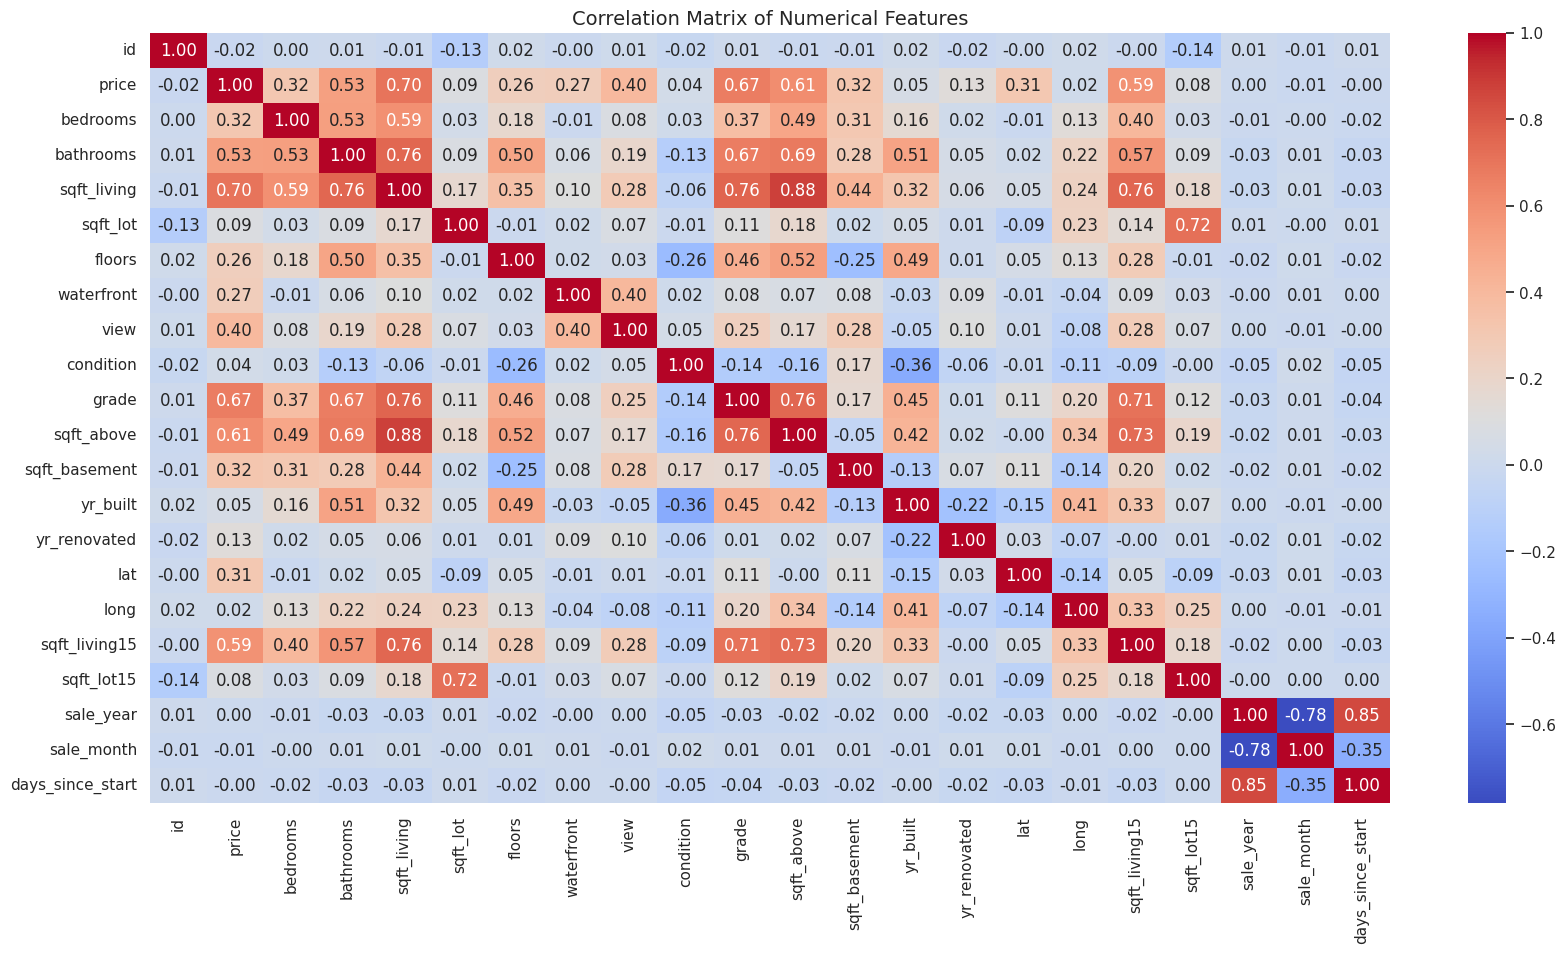

In [15]:
# --- Linear correlations plot

corr_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

 **Key predictors of house price:**



 *   sqft_living (0.70): This is the strongest predictor. The single biggest factor in a home's price is its size.



 *   grade (0.67): This is also a very strong predictor. It represents the quality of construction and design. This tells us that high-quality construction is almost as important as size in determining price.



 * sqft_above (0.61) & sqft_living15 (0.59): These are also very strong. sqft_living15 is particularly interesting since it shows that the size of neighboring houses is a powerful indicator of a home's price.



 * bathrooms (0.53): More bathrooms strongly correlate with a higher price.



 * lat (Latitude) (0.31): In King County, higher latitude generally corresponds to more desirable and expensive neighborhoods north of Seattle. This may be due to their proximity to the center of Seattle.





 **Strong Multicollinearity:**



 *   sqft_living and sqft_above (0.88): They are highly redundant since sqft_living is the sum of sqft_above and sqft_basement.



 *   sqft_living and grade (0.76): Bigger houses seem to tend to be built to a higher grade/quality.



 * sale_year and days_since_start (0.85): "Mechanical relationship" from feature engineering. They are essentially the same information.



 * sale_year and sale_month (-0.78): This strong negative correlation is an artifact of the dataset's time range. The data likely spans from 2014-10-29 to 2015-05-27. Therefore, sales in 2014 have high month numbers (5,12), while sales in 2015 have low month numbers (1,5), creating the negative trend.





 **Other insight:**







 *   condition vs. price (0.04): This very low relationship implies that the cosmetic condition of a house is FAR less important to its price than its "grade".

 *   view and waterfront: These features have a decent correlation with price (0.40 and 0.27), but their correlation with each other is also remarkable (0.40). A house with waterfront is almost certain to have a great view.

 # Feature Engineering

In [16]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month',
       'days_since_start'],
      dtype='object')

In [17]:
# --- New features created through interactions

df["ratio_living_size15"] = df["sqft_living"] / df["sqft_living15"]
df["ratio_lot_size15"] = df["sqft_lot"] / df["sqft_lot15"]
df["living_lot_ratio"] = df["sqft_living"] / df["sqft_lot"]
df["volume"] = df["floors"] * df["sqft_living"]

# Binary flags from sparse columns
df["was_renovated"] = (df["yr_renovated"] > 0).astype(int)                      # Most houses are never renovated
df["has_basement"] = (df["sqft_basement"] > 0).astype(int)

# Simple ratios
df["bath_per_bed"] = np.where(df["bedrooms"] > 0, df["bathrooms"] / df["bedrooms"], 0.0)
df["basement_ratio"] = df["sqft_basement"] / df["sqft_living"]


print(df[["ratio_living_size15", "ratio_lot_size15", "living_lot_ratio", "volume", "was_renovated", "has_basement", "bath_per_bed", "basement_ratio"]].head())

   ratio_living_size15  ratio_lot_size15  living_lot_ratio  volume  \
0             0.880597          1.000000          0.208850  1180.0   
1             1.520710          0.948030          0.354874  5140.0   
2             0.283088          1.240387          0.077000   770.0   
3             1.441176          1.000000          0.392000  1960.0   
4             0.933333          1.076903          0.207921  1680.0   

   was_renovated  has_basement  bath_per_bed  basement_ratio  
0              0             0      0.333333        0.000000  
1              1             1      0.750000        0.155642  
2              0             0      0.500000        0.000000  
3              0             1      0.750000        0.464286  
4              0             0      0.666667        0.000000  


In [18]:
# --- How old is the house?

# Let's assume that a renovated house is considered as new.
# If yr_renovated > 0, the house was renovated: age = sale_year - renovation year.
# Otherwise, age = sale_year - construction year.
df["age"] = np.where(df["yr_renovated"] > 0,
                     df["sale_year"] - df["yr_renovated"],
                     df["sale_year"] - df["yr_built"])

print(df["age"].head())

0    59
1    23
2    82
3    49
4    28
Name: age, dtype: int64


In [19]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,21611.0,4580296884.462773,1000102.0,2123049184.5,3904930410.0,7308900467.5,9900000190.0,2876653454.727373
date,21611,2014-10-29 04:55:46.962195200,2014-05-02 00:00:00,2014-07-22 00:00:00,2014-10-16 00:00:00,2015-02-17 00:00:00,2015-05-27 00:00:00,NaN
price,21611.0,540027.502568,75000.0,321725.0,450000.0,645000.0,7700000.0,367088.793612
bedrooms,21611.0,3.369765,0.0,3.0,3.0,4.0,11.0,0.907427
bathrooms,21611.0,2.114953,0.0,1.75,2.25,2.5,8.0,0.76993
sqft_living,21611.0,2079.72787,290.0,1426.0,1910.0,2550.0,13540.0,918.271201
sqft_lot,21611.0,15106.849197,520.0,5040.0,7618.0,10687.5,1651359.0,41422.275478
floors,21611.0,1.494193,1.0,1.0,1.5,2.0,3.5,0.539831
waterfront,21611.0,0.007542,0.0,0.0,0.0,0.0,1.0,0.086521
view,21611.0,0.234233,0.0,0.0,0.0,0.0,4.0,0.766257


In [20]:
# --- One-hot encoding

# One-hot encoding of the seasoning

month_to_season_map = {                                                         # For the value of each month we assign it to the season
    1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall",
    12: "Winter"
}


df["season"] = df["sale_month"].map(month_to_season_map)                        # Apply the map

print(df[["sale_month", "season"]].sample(5))                                   # sale_month and the assigned season

print("Distribution of sales by season:")
print(df["season"].value_counts())

       sale_month  season
18439           5  Spring
12760           9    Fall
7109            8  Summer
2926            7  Summer
18621           1  Winter
Distribution of sales by season:
season
Spring    6520
Summer    6329
Fall      5063
Winter    3699
Name: count, dtype: int64


In [21]:
# --- Distance from different cities (km)

city_centers = {
    "center":   (47.620564, -122.350616),                                       # Seattle center
    "medina":   (47.62093, -122.22762),
    "kirkland": (47.684830594, -122.18833258),
    "bellevue": (47.610378, -122.200676),
    "redmond":  (47.673988, -122.121513),
    "issaquah": (47.530102, -122.032616),
    "renton":   (47.482880, -122.217064),
    "kent":     (47.378010, -122.237381),
    "seatac":   (47.438164914, -122.28916551)
}

house_coords = df[["lat", "long"]].to_numpy()                                   # Vectorized input (N x 2)

for city_name, center in city_centers.items():
    city_point = np.array(center).reshape(1, 2)
    df[f"dist_to_{city_name}"] = haversine_vector(
        house_coords, city_point, Unit.KILOMETERS, comb=True
    ).ravel()                                   # flatten (1, N) or (N, 1) -> (N,)

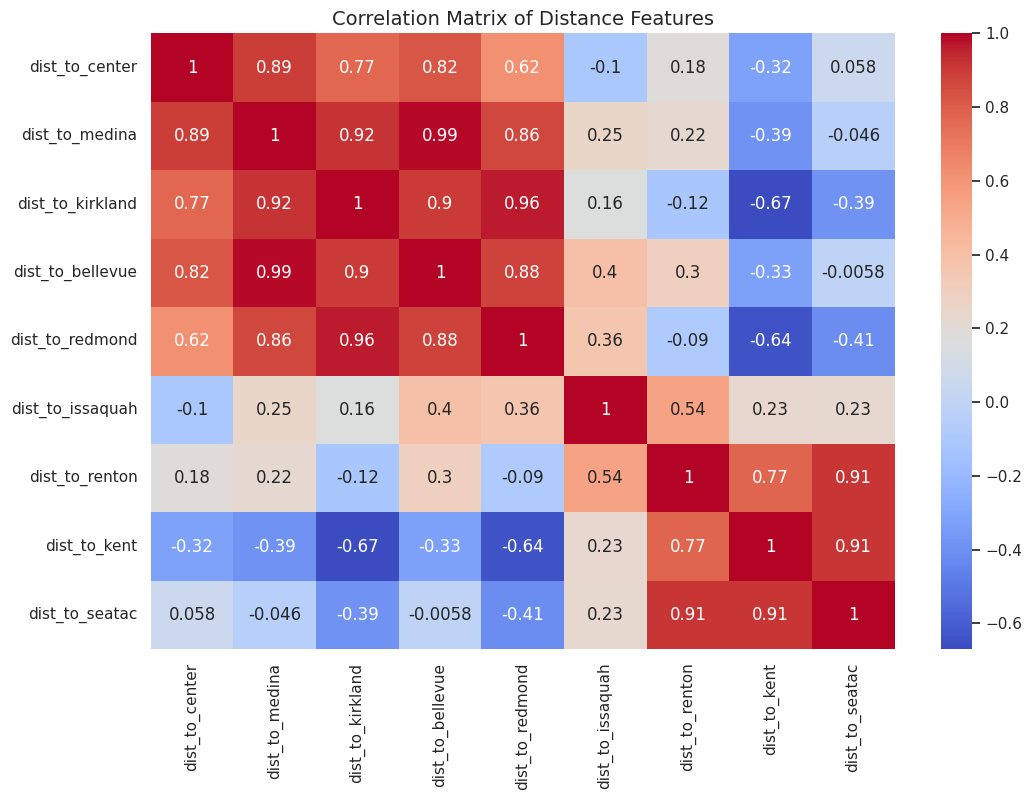

In [22]:
# Matrix correlation of previous distances

dist_cols = [f"dist_to_{city_name}" for city_name in city_centers]

# Distance to the NEAREST city center
df["dist_to_nearest_city"] = df[dist_cols].min(axis=1)
corr_matrix = df[dist_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Distance Features")
plt.show()

 We can see that a lot of dist are are highly linearly correlated with each other. This is probably caused by their proximity.

In [23]:
# --- VIF (Variance Inflation Factor)

# VIF is meaningful only on predictors -> exclude the target variable "price"
sel_vif = df.select_dtypes(include=np.number).drop(columns=["price"])
vif_data = pd.DataFrame()
vif_data["feature"] = sel_vif.columns
vif_data["VIF"] = [variance_inflation_factor(sel_vif.values, i) for i in range(len(sel_vif.columns))]
print(vif_data)

divide by zero encountered in scalar divide


                 feature           VIF
0                     id  3.684709e+00
1               bedrooms  7.716279e+00
2              bathrooms  1.460836e+01
3            sqft_living           inf
4               sqft_lot  3.479791e+00
5                 floors  1.032942e+01
6             waterfront  1.226434e+00
7                   view  1.488316e+00
8              condition  1.293817e+00
9                  grade  3.708297e+00
10            sqft_above           inf
11         sqft_basement           inf
12              yr_built  4.378041e+01
13          yr_renovated  1.954061e+04
14                   lat  4.203604e+01
15                  long  2.219970e+01
16         sqft_living15  1.609020e+01
17            sqft_lot15  2.961633e+00
18             sale_year  1.164175e+00
19            sale_month  1.486876e+00
20      days_since_start  1.650268e+00
21   ratio_living_size15  9.805111e+00
22      ratio_lot_size15  1.709722e+00
23      living_lot_ratio  2.971103e+00
24                volume 

 From the VIF values, we can observe that some features have VERY high values. The choice of which variables to keep will be made subsequently by the ElasticNet model (for linear regression) and by RFECV (Random Forest) for non-linear models.

In [24]:
# --- Train/Test index split BEFORE clustering (prevents data leakage)

train_idx, test_idx = train_test_split(df.index, test_size=0.3, random_state=42)

 ## Clustering Processes



 For this part, I decided to try 3 different clustering methods:



 *   K-Means,

 *   HDBSCAN,

 *   Gaussian mixture models (GMM)

In [25]:
# --- Geographic Preprocessing

# We will use a single, projected coordinate system (UTM Zone 10N for King County) for all clustering algorithms to ensure they are comparable in the results.
# The output units will be in meters.
transformer = Transformer.from_crs("epsg:4326", "epsg:32610", always_xy=True)           # epsg:4326 -> lat and long in original data ||| epsg:32610 -> UTM Zone 10N
inverse_transformer = Transformer.from_crs("epsg:32610", "epsg:4326", always_xy=True)   # Used later to plot cluster centers back on lat/long
xx, yy = transformer.transform(df["long"].values, df["lat"].values)

X_geo_utm = pd.DataFrame({"easting": xx, "northing": yy}, index=df.index)       # DataFrame input for all the models

print("Data prepared for all clustering methods using UTM projection:")
print(X_geo_utm.head())

X_geo_utm_train = X_geo_utm.loc[train_idx]                                      # Clustering input: TRAINING houses only
print(f"Clusterers will be fit on {len(train_idx)} training houses")

Data prepared for all clustering methods using UTM projection:
         easting      northing
0  555945.841580  5.262242e+06
1  551072.719321  5.285516e+06
2  557503.790457  5.287454e+06
3  545697.119225  5.263220e+06
4  571764.358413  5.274152e+06
Clusterers will be fit on 15127 training houses


 ### K-Means

In [26]:
# --- K-Means doesn't require assumptions or special tuning. We can directly compute the Silhouette, Calinski-Harabasz, and Davies-Bouldin scores

k_range = range(2, 31)                                                          # Can be chosen from 2 to 30 cluster

silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

print("Calculating k-means metrics.")
for k in k_range:
    kmeans = KMeans(n_clusters=k,
                    init="k-means++",                                           # Non-random initial center position
                    random_state=42,
                    n_init=10)                                                  # Run 10 times independently with different random starting points for the cluster centers

    kmeans.fit(X_geo_utm_train)                                                 # Actual fit (TRAINING houses only -> no leakage)
    labels = kmeans.labels_

    # Calculate Silhouette Score (higher is better)
    sil_score = silhouette_score(X_geo_utm_train, labels)
    silhouette_scores.append(sil_score)

    # Calculate Calinski-Harabasz Score (higher is better)
    ch_score = calinski_harabasz_score(X_geo_utm_train, labels)
    calinski_harabasz_scores.append(ch_score)

    # Calculate Davies-Bouldin Score (lower is better)
    db_score = davies_bouldin_score(X_geo_utm_train, labels)
    davies_bouldin_scores.append(db_score)

print("Calculation complete.")

Calculating k-means metrics.
Calculation complete.


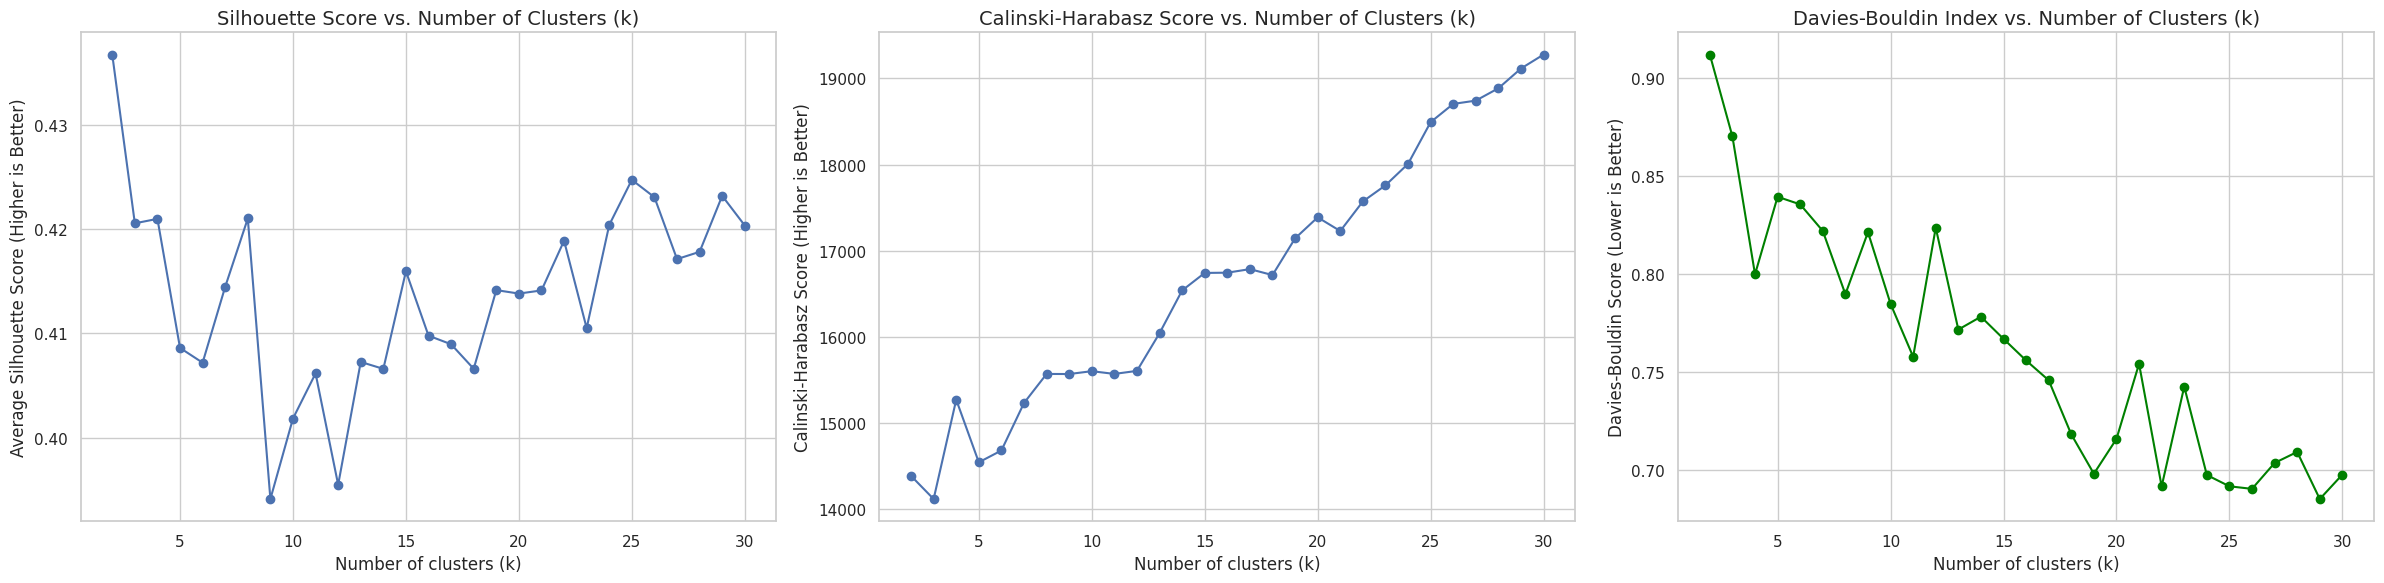

In [27]:
# --- Plot the results

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

# Plot Silhouette Scores
ax1.plot(k_range, silhouette_scores, marker="o")
ax1.set_title("Silhouette Score vs. Number of Clusters (k)")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Average Silhouette Score (Higher is Better)")
ax1.grid(True)

# Plot Calinski-Harabasz Scores
ax2.plot(k_range, calinski_harabasz_scores, marker="o")
ax2.set_title("Calinski-Harabasz Score vs. Number of Clusters (k)")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Calinski-Harabasz Score (Higher is Better)")
ax2.grid(True)

# Plot Davies-Bouldin Scores
ax3.plot(k_range, davies_bouldin_scores, marker="o", color="green")
ax3.set_title("Davies-Bouldin Index vs. Number of Clusters (k)")
ax3.set_xlabel("Number of clusters (k)")
ax3.set_ylabel("Davies-Bouldin Score (Lower is Better)")
ax3.grid(True)

plt.tight_layout()
plt.show()

 From these plots we can observe that 8 is an optimal value for the number of clusters of the K-Means

In [28]:
# --- Apply K-Means and Create the Feature
# After the "exploratory phase" we have selected k and we can create the new feature

optimal_k = 8
kmeans = KMeans(n_clusters=optimal_k,
                init="k-means++",
                random_state=42,
                n_init=10)

kmeans.fit(X_geo_utm_train)
df["kmeans_cluster"] = kmeans.predict(X_geo_utm)

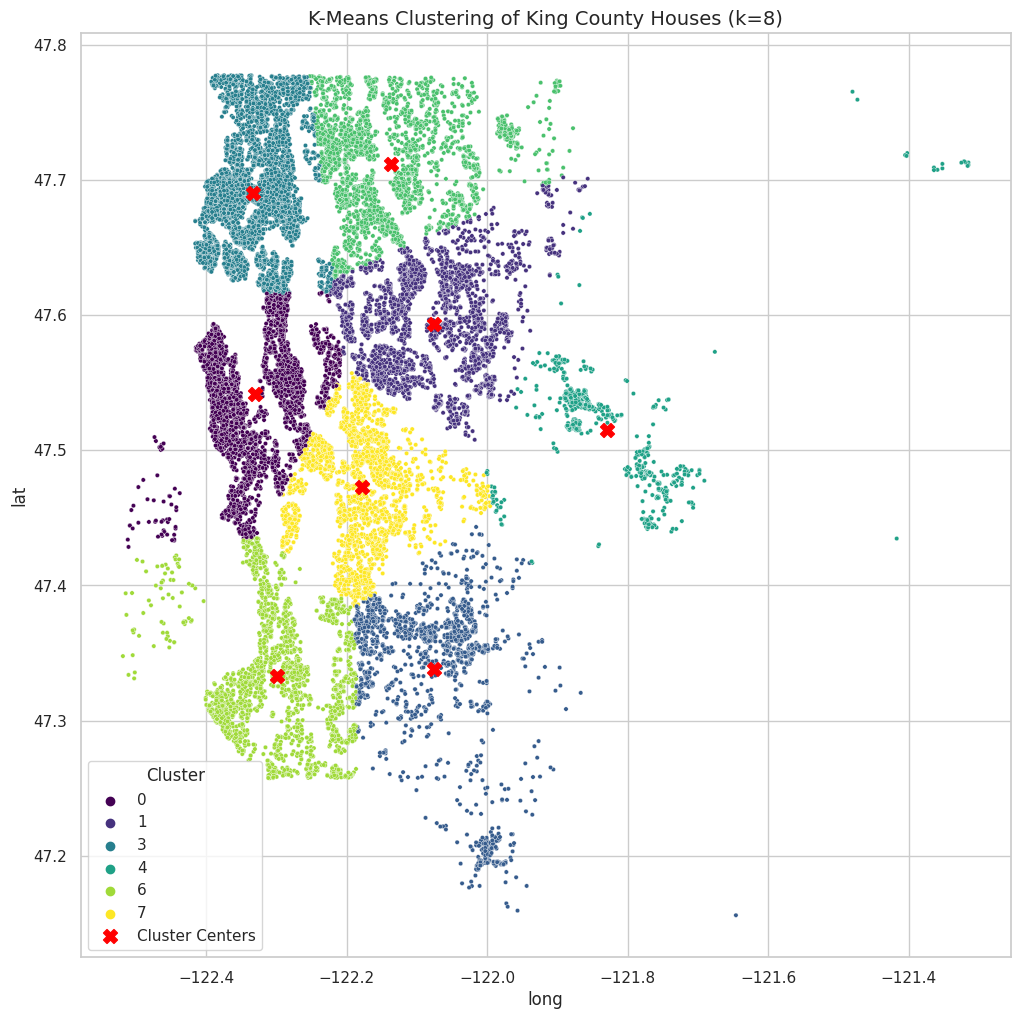

In [29]:
# --- Visualization
# We visualize on the original lat/long, but color by the new cluster labels

plt.figure(figsize=(12, 12))
ax = plt.gca()
sns.scatterplot(data=df, x="long", y="lat", hue="kmeans_cluster", palette="viridis", s=10, ax=ax)

# Add cluster centers (projected back to lat/long with the inverse transformer defined above)
kmeans_centers_proj = kmeans.cluster_centers_
kmeans_centers_orig = inverse_transformer.transform(kmeans_centers_proj[:, 0], kmeans_centers_proj[:, 1])
ax.scatter(kmeans_centers_orig[0], kmeans_centers_orig[1], c="red", s=100, marker="X", label="Cluster Centers")

plt.title(f"K-Means Clustering of King County Houses (k={optimal_k})")
plt.legend(title="Cluster")
plt.show()

 ### HDBSCAN

In [30]:
# --- HDBSCAN does not require tuning "eps": it builds a hierarchy of density
# levels and extracts the most stable clusters automatically.
# min_cluster_size: smallest grouping size considered a cluster
# min_samples: how conservative the clustering is (higher -> more noise)

min_cluster_size_range = [50, 100, 150, 200, 250, 300, 350, 400, 500, 600, 700, 800, 900, 1000]                               # Candidate values for the smallest cluster size

silhouette_scores_hdbscan = []
calinski_harabasz_scores_hdbscan = []
davies_bouldin_scores_hdbscan = []
noise_fraction_hdbscan = []

print("HDBSCAN clustering for different min_cluster_size values.")
for mcs in min_cluster_size_range:
    hdb = hdbscan.HDBSCAN(min_cluster_size=mcs,
                          min_samples=15,                                       # Same conservativeness as the previous DBSCAN analysis
                          metric="euclidean")
    labels = hdb.fit_predict(X_geo_utm_train)                                   # Fit on TRAINING houses only

    # Exclude outliers for metric calculation (where the label is -1).
    mask = labels != -1
    noise_fraction_hdbscan.append(1 - mask.mean())
    if len(set(labels[mask])) > 1:                                              # Checks if there is more than one cluster found.
        silhouette_scores_hdbscan.append(silhouette_score(X_geo_utm_train[mask], labels[mask]))
        calinski_harabasz_scores_hdbscan.append(calinski_harabasz_score(X_geo_utm_train[mask], labels[mask]))
        davies_bouldin_scores_hdbscan.append(davies_bouldin_score(X_geo_utm_train[mask], labels[mask]))
    else:                                                                       # If only one cluster is found (or none) -> non applicable metrics
        silhouette_scores_hdbscan.append(np.nan)
        calinski_harabasz_scores_hdbscan.append(np.nan)
        davies_bouldin_scores_hdbscan.append(np.nan)

print("Calculation complete.")

HDBSCAN clustering for different min_cluster_size values.
Calculation complete.


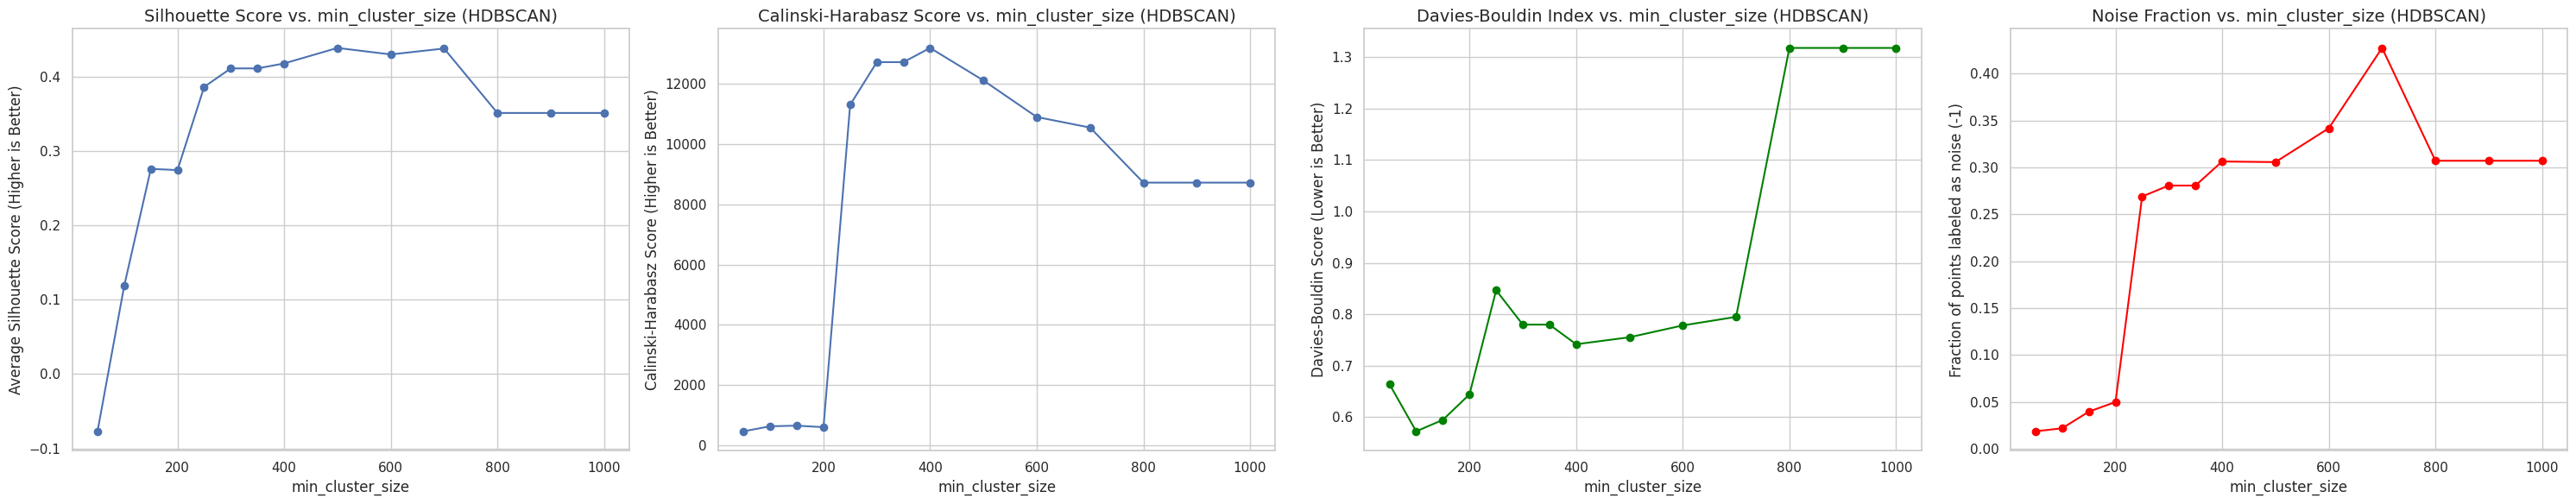

In [31]:
# --- Plot the results

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(30, 6))

ax1.plot(min_cluster_size_range, silhouette_scores_hdbscan, marker="o")
ax1.set_title("Silhouette Score vs. min_cluster_size (HDBSCAN)")
ax1.set_xlabel("min_cluster_size")
ax1.set_ylabel("Average Silhouette Score (Higher is Better)")
ax1.grid(True)

ax2.plot(min_cluster_size_range, calinski_harabasz_scores_hdbscan, marker="o")
ax2.set_title("Calinski-Harabasz Score vs. min_cluster_size (HDBSCAN)")
ax2.set_xlabel("min_cluster_size")
ax2.set_ylabel("Calinski-Harabasz Score (Higher is Better)")
ax2.grid(True)

ax3.plot(min_cluster_size_range, davies_bouldin_scores_hdbscan, marker="o", color="green")
ax3.set_title("Davies-Bouldin Index vs. min_cluster_size (HDBSCAN)")
ax3.set_xlabel("min_cluster_size")
ax3.set_ylabel("Davies-Bouldin Score (Lower is Better)")
ax3.grid(True)

ax4.plot(min_cluster_size_range, noise_fraction_hdbscan, marker="o", color="red")
ax4.set_title("Noise Fraction vs. min_cluster_size (HDBSCAN)")
ax4.set_xlabel("min_cluster_size")
ax4.set_ylabel("Fraction of points labeled as noise (-1)")
ax4.grid(True)

plt.tight_layout()
plt.show()

From these plots we select the value of "min_cluster_size" that balances cluster quality (Silhouette / Davies-Bouldin) against the fraction of houses discarded as noise: a very low noise action usually means one giant cluster, while a very high one discards too much spatial information.

In [32]:
# --- Apply HDBSCAN to the dataset

optimal_min_cluster_size = 400                                                  # Manually selected after inspecting the plots above

hdb_final = hdbscan.HDBSCAN(min_cluster_size=optimal_min_cluster_size,
                            min_samples=15,
                            metric="euclidean",
                            prediction_data=True
                           )

# Fit on the TRAINING houses only...
train_labels_hdb = hdb_final.fit_predict(X_geo_utm_train)

# ...then label the TEST houses with the native approximate_predict(), which
# extends the fitted hierarchy to unseen points (no manual NN workaround needed).
test_labels_hdb, test_strengths = hdbscan.approximate_predict(hdb_final, X_geo_utm.loc[test_idx])

df["hdbscan_cluster"] = -1
df.loc[train_idx, "hdbscan_cluster"] = train_labels_hdb
df.loc[test_idx, "hdbscan_cluster"] = test_labels_hdb

# The cluster label "-1" is for outliers/noise.
print(f"Number of clusters found: {len(set(train_labels_hdb)) - (1 if -1 in train_labels_hdb else 0)}")
print(f"Number of outliers (train): {list(train_labels_hdb).count(-1)}")
print(f"Number of outliers (test): {list(test_labels_hdb).count(-1)}")

Number of clusters found: 10
Number of outliers (train): 4635
Number of outliers (test): 2175


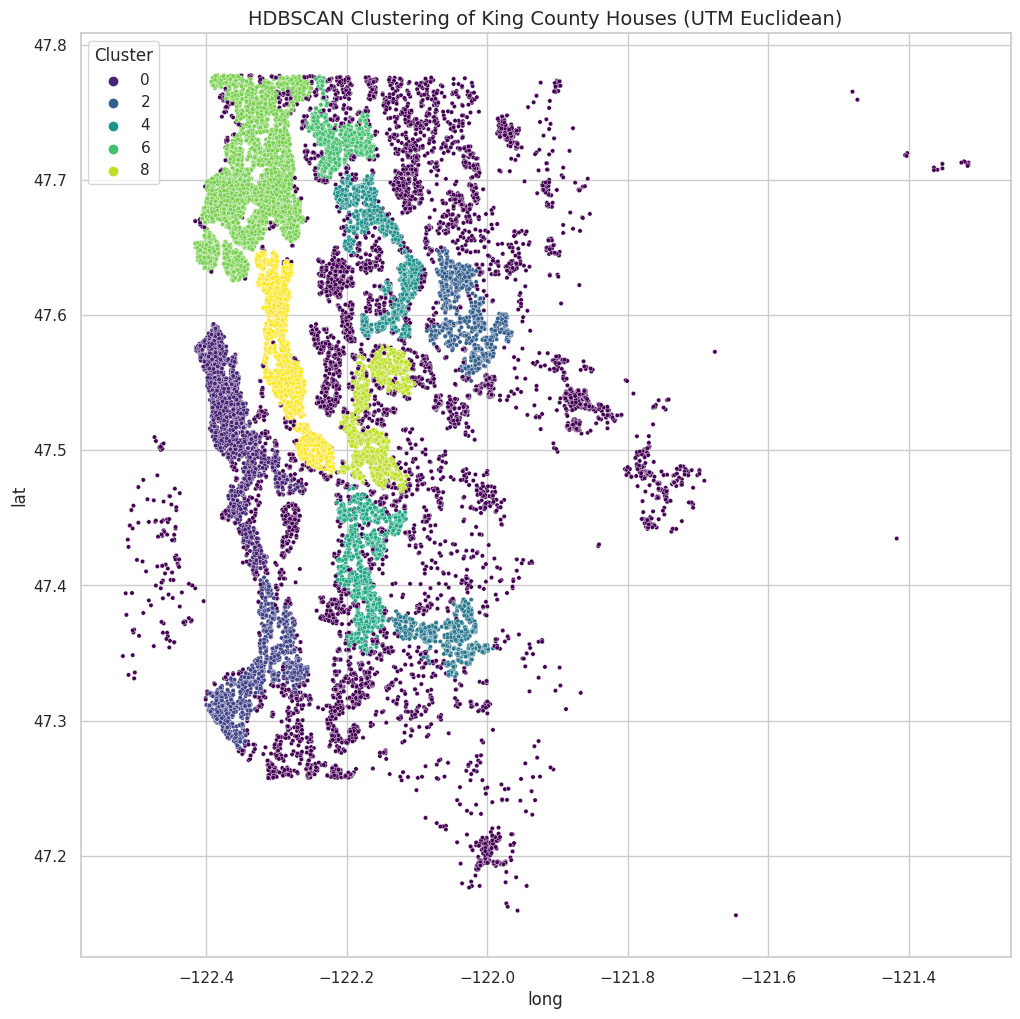

In [33]:
# --- HDBSCAN visualization

plt.figure(figsize=(12, 12))
sns.scatterplot(data=df, x="long", y="lat", hue="hdbscan_cluster", palette="viridis", s=10)
plt.title("HDBSCAN Clustering of King County Houses (UTM Euclidean)")
plt.legend(title="Cluster")
plt.show()

 ### Gaussian mixture models (GMM)

In [34]:
# --- Find the best GMM model

# We will try different combinations of the number of clusters and the covariance type
n_components_range = range(2, 30)                                               # A good range to test

covariance_types = [                                                            # Covariance types
    "spherical",                                                                # Each cluster has the same, spherical shape
    "diag",                                                                     # Each cluster is an ellipse aligned with the axes
    "tied",                                                                     # All clusters have the same elliptical shape
    "full"]                                                                     # Each cluster can have its own, arbitrarily oriented elliptical shape

gmm_results = []

print("Start GMM analysis")
for cov_type in covariance_types:
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components,                        # Number of clusters
                              covariance_type=cov_type,                         # Covariance type
                              random_state=42)

        gmm.fit(X_geo_utm_train)                                                # Fit (TRAINING houses only -> no leakage)
        labels = gmm.predict(X_geo_utm_train)

        gmm_results.append({                                                    # Store the results
            "n_components": n_components,
            "covariance_type": cov_type,
            "bic": gmm.bic(X_geo_utm_train),
            "aic": gmm.aic(X_geo_utm_train),
            "silhouette": silhouette_score(X_geo_utm_train, labels),
            "calinski_harabasz": calinski_harabasz_score(X_geo_utm_train, labels),
            "davies_bouldin": davies_bouldin_score(X_geo_utm_train, labels),
        })

print("Analysis complete.")

Start GMM analysis
Analysis complete.


In [35]:
# --- From raw results to dataframe for better analysis

results_df = pd.DataFrame(gmm_results)
results_df

,n_components,covariance_type,bic,aic,silhouette,calinski_harabasz,davies_bouldin
0,2,spherical,655450.212067,655396.842411,0.437546,14224.051962,0.918080
1,3,spherical,654405.586029,654321.719427,0.416959,13702.971277,0.843574
2,4,spherical,651756.727857,651642.364310,0.376341,13112.272822,0.791444
3,5,spherical,651455.061921,651310.201427,0.402822,14093.111993,0.816774
4,6,spherical,650771.074859,650595.717419,0.394755,13016.988389,0.781203
...,...,...,...,...,...,...,...
107,25,full,641046.018142,639910.006902,0.387860,15539.798382,0.740194
108,26,full,641098.180961,639916.424303,0.387299,15874.234636,0.744052
109,27,full,640982.954540,639755.452463,0.383797,15390.538685,0.768001
110,28,full,640774.065176,639500.817679,0.383497,15162.054018,0.761653


In [36]:
# --- Displaying the BIC and AIC results (similar to an R output...) (I like R)

print("BIC Scores (Lower is better)")
bic_pivot = results_df.pivot(index="n_components", columns="covariance_type", values="bic")
print(bic_pivot)


print("AIC Scores (Lower is better)")
aic_pivot = results_df.pivot(index="n_components", columns="covariance_type", values="aic")
print(aic_pivot)

BIC Scores (Lower is better)
covariance_type           diag           full      spherical           tied
n_components                                                               
2                655465.565711  655201.284236  655450.212067  655906.854958
3                652300.724111  651745.459052  654405.586029  654527.661619
4                651364.841718  650770.093966  651756.727857  653290.492391
5                650522.184380  650218.513178  651455.061921  652995.774222
6                649920.499220  649503.419917  650771.074859  652644.480642
7                648827.956444  648318.429781  650491.185638  651193.392188
8                648218.303077  647960.390152  650081.121230  650629.973467
9                648106.159461  645553.632364  649961.637094  650661.906878
10               647996.583044  645585.605087  649549.134100  650298.643487
11               648127.597222  645457.476092  649459.989866  649765.624951
12               647682.386133  645030.659607  648395.16657

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN be

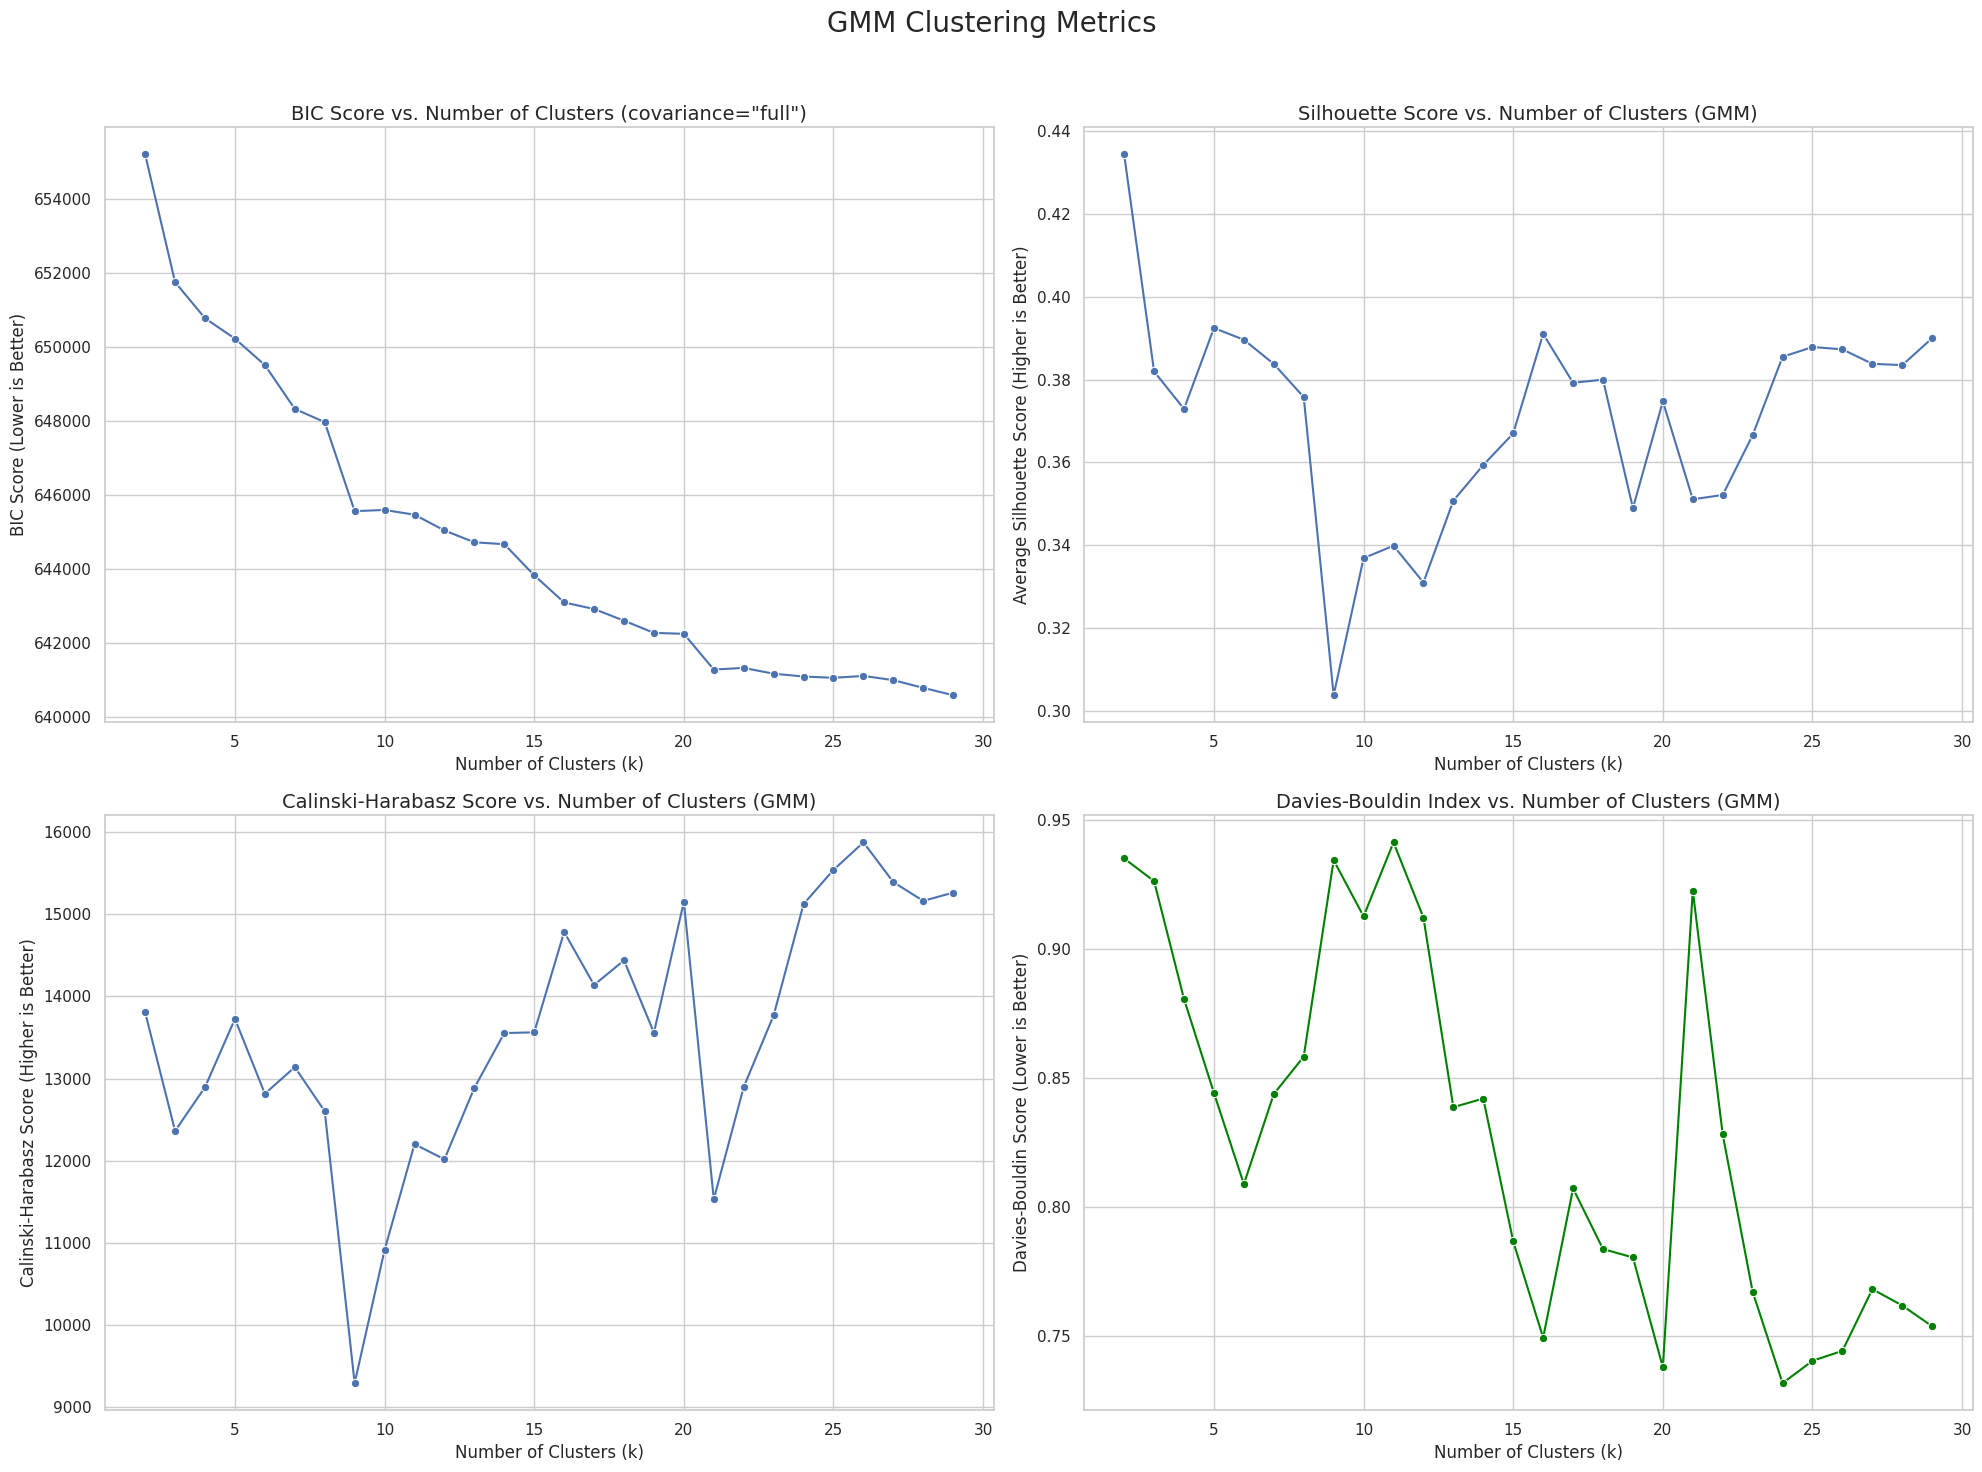

In [37]:
# --- GMM Score Plots

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle("GMM Clustering Metrics", fontsize=20)

# BIC Plot

best_model = results_df.loc[results_df["bic"].idxmin()]
best_cov_type = best_model["covariance_type"]

plot_data = results_df[results_df["covariance_type"] == best_cov_type]
sns.lineplot(data=plot_data, x="n_components", y="bic", marker="o", ax=axes[0, 0])
axes[0, 0].set_title(f'BIC Score vs. Number of Clusters (covariance="{best_cov_type}")')
axes[0, 0].set_xlabel("Number of Clusters (k)")
axes[0, 0].set_ylabel("BIC Score (Lower is Better)")
axes[0, 0].grid(True)


# Silhouette Score Plot
sns.lineplot(data=plot_data, x="n_components", y="silhouette", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Silhouette Score vs. Number of Clusters (GMM)")
axes[0, 1].set_xlabel("Number of Clusters (k)")
axes[0, 1].set_ylabel("Average Silhouette Score (Higher is Better)")
axes[0, 1].grid(True)


# Calinski-Harabasz Score Plot
sns.lineplot(data=plot_data, x="n_components", y="calinski_harabasz", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Calinski-Harabasz Score vs. Number of Clusters (GMM)")
axes[1, 0].set_xlabel("Number of Clusters (k)")
axes[1, 0].set_ylabel("Calinski-Harabasz Score (Higher is Better)")
axes[1, 0].grid(True)


# Davies-Bouldin Score Plot
sns.lineplot(data=plot_data, x="n_components", y="davies_bouldin", marker="o", color="green", ax=axes[1, 1])
axes[1, 1].set_title("Davies-Bouldin Index vs. Number of Clusters (GMM)")
axes[1, 1].set_xlabel("Number of Clusters (k)")
axes[1, 1].set_ylabel("Davies-Bouldin Score (Lower is Better)")
axes[1, 1].grid(True)


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

 From these plots we can observe that 19 is an optimal value for the number of clusters of the GMM

In [38]:
# --- Best model based on BIC

best_model_bic = results_df.loc[results_df["bic"].idxmin()]
print("Best model according to BIC:")
print(best_model_bic)

Best model according to BIC:
n_components                    29
covariance_type               full
bic                  640576.078389
aic                  639257.085473
silhouette                0.390002
calinski_harabasz     15263.001067
davies_bouldin            0.753571
Name: 111, dtype: object


 Covariance_type="full" allows for complex cluster shapes, it gives the GMM power to fit the data very precisely.

In [39]:
# --- Manual Selection + Fit

best_n_components_gmm = 19                                                      # Manually selected
best_cov_type_gmm = "full"                                                      # From the previous table, we can see that for k=19 the best cov is "full"

best_gmm = GaussianMixture(n_components=best_n_components_gmm,
                           covariance_type=best_cov_type_gmm,
                           random_state=42)

best_gmm.fit(X_geo_utm_train)                                                   # Fit on TRAINING houses only

GaussianMixture(n_components=19, random_state=42)

In [40]:
# --- Apply the Best GMM and Create Features
# GMM has the "power" to do hard and soft clustering. Let's create both for "test" (we will keep only one later)

# 1. Hard Clustering
df["gmm_cluster"] = best_gmm.predict(X_geo_utm)                                 # New feature of the cluster label

# 2. Soft Clustering (KEY ADVANTAGE OF GMM)
cluster_probabilities = best_gmm.predict_proba(X_geo_utm)                       # Probability that the house belongs to each of the clusters
prob_df = pd.DataFrame(cluster_probabilities,                                   # New dataframe with the probabilities
                       columns=[f"gmm_prob_{i}" for i in range(best_gmm.n_components)],
                       index=df.index)

# Robustly join the new features, removing old ones if they exist
cols_to_drop = df.filter(like="gmm_prob_").columns                              # If run multiple times GMM
df = df.drop(columns=cols_to_drop).join(prob_df)                                # Add new probabilities to the original dataset

print("New features created:")
print(df.filter(regex="gmm_").head())

New features created:
   gmm_cluster    gmm_prob_0    gmm_prob_1    gmm_prob_2    gmm_prob_3  \
0           18  9.606542e-15  2.464798e-01  1.203058e-09  4.492922e-15   
1            0  6.669364e-01  9.561158e-09  2.240263e-06  4.522980e-67   
2            7  1.668780e-02  2.545020e-08  2.733884e-07  1.850403e-69   
3           12  1.409385e-08  9.083506e-02  2.310402e-10  1.542942e-23   
4           13  2.529722e-20  7.805432e-05  3.984632e-01  5.891110e-32   

     gmm_prob_4    gmm_prob_5    gmm_prob_6    gmm_prob_7     gmm_prob_8  \
0  2.801462e-32  3.136282e-05  6.457655e-02  1.705159e-12   2.646806e-18   
1  2.952631e-12  1.048011e-23  3.425083e-14  8.312078e-03   1.201723e-14   
2  8.617382e-09  1.304256e-17  2.275330e-17  8.821915e-01   2.986291e-32   
3  4.439590e-52  1.002528e-24  2.014362e-08  3.495123e-20   3.427752e-38   
4  5.481432e-03  3.171797e-18  4.654735e-12  3.396276e-03  1.553031e-181   

     gmm_prob_9   gmm_prob_10   gmm_prob_11    gmm_prob_12   gmm_prob_13  \


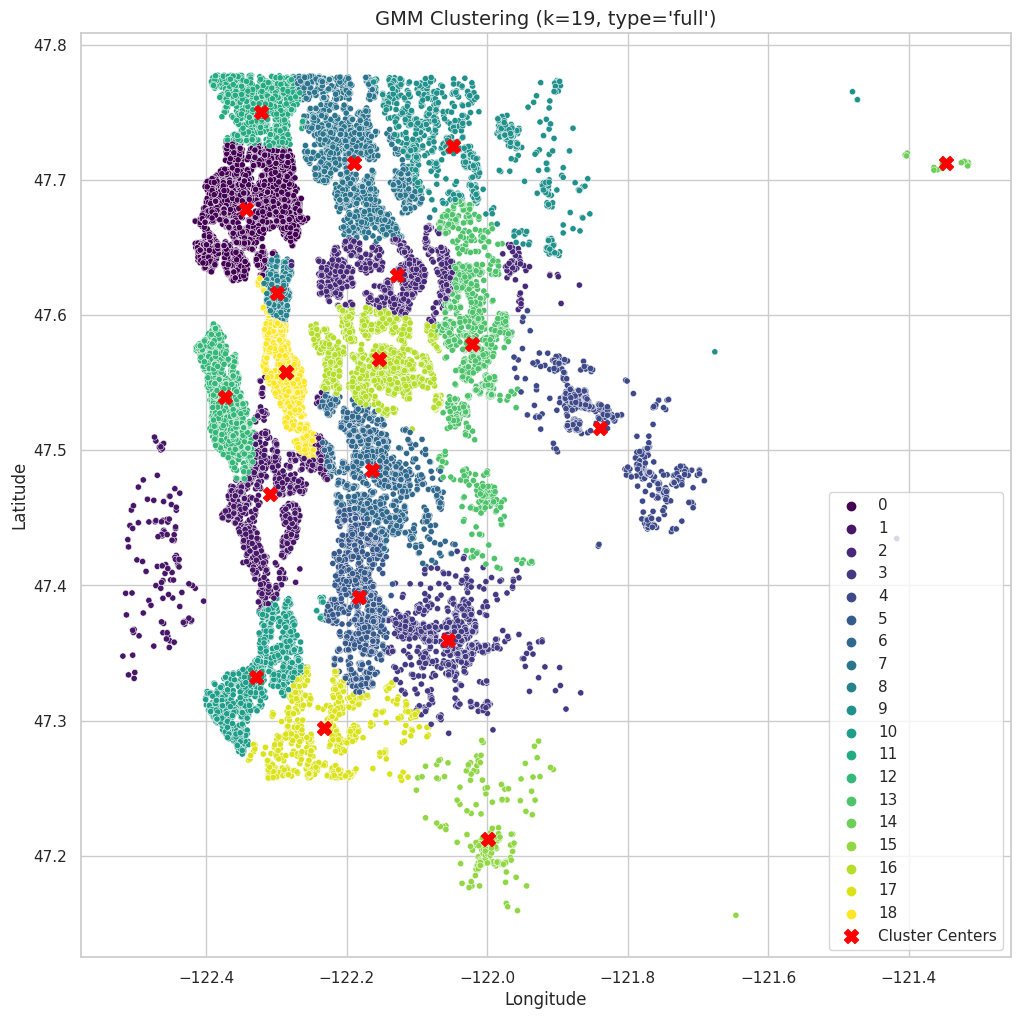

In [41]:
# --- Visualize GMM

plt.figure(figsize=(12, 12))
ax = plt.gca()
sns.scatterplot(data=df, x="long", y="lat", hue="gmm_cluster", palette="viridis", s=20, ax=ax, legend="full")

# Add cluster centers (projected back to lat/long with the inverse transformer defined above)
original_centers = inverse_transformer.transform(best_gmm.means_[:, 0], best_gmm.means_[:, 1])

ax.scatter(original_centers[0], original_centers[1], c="red", s=100, marker="X", label="Cluster Centers")
plt.title(f"GMM Clustering (k={best_gmm.n_components}, type='{best_gmm.covariance_type}')")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

In [42]:
# --- FINAL MODEL COMPARISON TABLE
gmm_metrics_row = results_df[(results_df["n_components"] == best_n_components_gmm) & (results_df["covariance_type"] == best_cov_type_gmm)]


cluster_models = [
    ("K-Means (k=8)", {
        
        "Silhouette Score": silhouette_scores[optimal_k - 2],
        "Calinski-Harabasz Score": calinski_harabasz_scores[optimal_k - 2],
        "Davies-Bouldin Score": davies_bouldin_scores[optimal_k - 2]
    }),
    ("HDBSCAN (min_cluster_size=400, min_samples=15)", {
        "Silhouette Score": silhouette_scores_hdbscan[min_cluster_size_range.index(optimal_min_cluster_size)],
        "Calinski-Harabasz Score": calinski_harabasz_scores_hdbscan[min_cluster_size_range.index(optimal_min_cluster_size)],
        "Davies-Bouldin Score": davies_bouldin_scores_hdbscan[min_cluster_size_range.index(optimal_min_cluster_size)]
    }),
    ("GMM (k=19, cov='full')", {
        "Silhouette Score": gmm_metrics_row["silhouette"].iloc[0],
        "Calinski-Harabasz Score": gmm_metrics_row["calinski_harabasz"].iloc[0],
        "Davies-Bouldin Score": gmm_metrics_row["davies_bouldin"].iloc[0],
        "BIC Score": gmm_metrics_row["bic"].iloc[0]
    })
]

# Create the comparison DataFrame
comparison_df = pd.DataFrame({name: metrics for name, metrics in cluster_models}).T

# Print
print("--- FINAL CLUSTERING MODEL COMPARISON ---")
print("Metrics Interpretation:")
print("- Silhouette Score: Higher is better (range -1 to 1)")
print("- Calinski-Harabasz Score: Higher is better (no fixed range)")
print("- Davies-Bouldin Score: Lower is better (min 0, no fixed upper bound)")
print("- BIC Score (GMM only): Lower is better (no fixed range)")
print(comparison_df.to_string())

--- FINAL CLUSTERING MODEL COMPARISON ---
Metrics Interpretation:
- Silhouette Score: Higher is better (range -1 to 1)
- Calinski-Harabasz Score: Higher is better (no fixed range)
- Davies-Bouldin Score: Lower is better (min 0, no fixed upper bound)
- BIC Score (GMM only): Lower is better (no fixed range)
                                                Silhouette Score  Calinski-Harabasz Score  Davies-Bouldin Score    BIC Score
K-Means (k=8)                                           0.421023             15571.488098              0.789608          NaN
HDBSCAN (min_cluster_size=400, min_samples=15)          0.417811             13196.968562              0.741805          NaN
GMM (k=19, cov='full')                                  0.348967             13558.569946              0.780312  642261.5867


invalid value encountered in greater
invalid value encountered in less
invalid value encountered in greater


 At the end of this process, I choose to "carry forward" the GMM and HDBSCAN models. GMM is a more flexible version of k-means, and although k-means is higher on the Silhouette and Calinski-Harabasz scores, while GMM has lower values for Davies-Bouldin, the strength of GMM is that it provides us with the probabilities that each observation belongs to a given cluster. We also "carry forward" HDBSCAN for its very low Calinski-Harabasz score and its ability to determine the different areas of Seattle (as analyzed previously).

 ## Deleting unused features

In [43]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,21603,21604,21605,21606,21607,21608,21609,21610,21611,21612
id,7129300520,6414100192,5631500400,2487200875,1954400510,7237550310,1321400060,2008000270,2414600126,3793500160,...,7852140040,9834201367,3448900210,7936000429,2997800021,263000018,6600060120,1523300141,291310100,1523300157
date,2014-10-13 00:00:00,2014-12-09 00:00:00,2015-02-25 00:00:00,2014-12-09 00:00:00,2015-02-18 00:00:00,2014-05-12 00:00:00,2014-06-27 00:00:00,2015-01-15 00:00:00,2015-04-15 00:00:00,2015-03-12 00:00:00,...,2014-08-25 00:00:00,2015-01-26 00:00:00,2014-10-14 00:00:00,2015-03-26 00:00:00,2015-02-19 00:00:00,2014-05-21 00:00:00,2015-02-23 00:00:00,2014-06-23 00:00:00,2015-01-16 00:00:00,2014-10-15 00:00:00
price,221900.0,538000.0,180000.0,604000.0,510000.0,1225000.0,257500.0,291850.0,229500.0,323000.0,...,507250.0,429000.0,610685.0,1007500.0,475000.0,360000.0,400000.0,402101.0,400000.0,325000.0
bedrooms,3,3,2,4,3,4,3,3,3,3,...,3,3,4,4,3,3,4,2,3,2
bathrooms,1.0,2.25,1.0,3.0,2.0,4.5,2.25,1.5,1.0,2.5,...,2.5,2.0,2.5,3.5,2.5,2.5,2.5,0.75,2.5,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gmm_prob_14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gmm_prob_15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gmm_prob_16,0.001992,0.0,0.0,0.0,0.00371,0.000002,0.0,0.0,0.000013,0.0,...,0.000001,0.010656,0.07267,0.000001,0.000003,0.0,0.0,0.005627,0.606672,0.005715
gmm_prob_17,0.0,0.0,0.0,0.0,0.0,0.0,0.100792,0.000005,0.0,0.00007,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
# --- Columns to drop:
# id: I mean...
# date: we worked on it and we extracted the "relative" features
# kmeans_cluster: we will use the gmm probs
# gmm_cluster: we will use the soft clustering of gmm
# gmm_prob_0: to prevent MULTICOLLINEARITY from ElasticNet

df.drop(columns=["id", "date", "kmeans_cluster", "gmm_cluster", "gmm_prob_0"], inplace=True)
df.T

,0,1,2,3,4,5,6,7,8,9,...,21603,21604,21605,21606,21607,21608,21609,21610,21611,21612
price,221900.0,538000.0,180000.0,604000.0,510000.0,1225000.0,257500.0,291850.0,229500.0,323000.0,...,507250.0,429000.0,610685.0,1007500.0,475000.0,360000.0,400000.0,402101.0,400000.0,325000.0
bedrooms,3,3,2,4,3,4,3,3,3,3,...,3,3,4,4,3,3,4,2,3,2
bathrooms,1.0,2.25,1.0,3.0,2.0,4.5,2.25,1.5,1.0,2.5,...,2.5,2.0,2.5,3.5,2.5,2.5,2.5,0.75,2.5,0.75
sqft_living,1180,2570,770,1960,1680,5420,1715,1060,1780,1890,...,2270,1490,2520,3510,1310,1530,2310,1020,1600,1020
sqft_lot,5650,7242,10000,5000,8080,101930,6819,9711,7470,6560,...,5536,1126,6023,7200,1294,1131,5813,1350,2388,1076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gmm_prob_14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gmm_prob_15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gmm_prob_16,0.001992,0.0,0.0,0.0,0.00371,0.000002,0.0,0.0,0.000013,0.0,...,0.000001,0.010656,0.07267,0.000001,0.000003,0.0,0.0,0.005627,0.606672,0.005715
gmm_prob_17,0.0,0.0,0.0,0.0,0.0,0.0,0.100792,0.000005,0.0,0.00007,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


 # Feature transformation

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


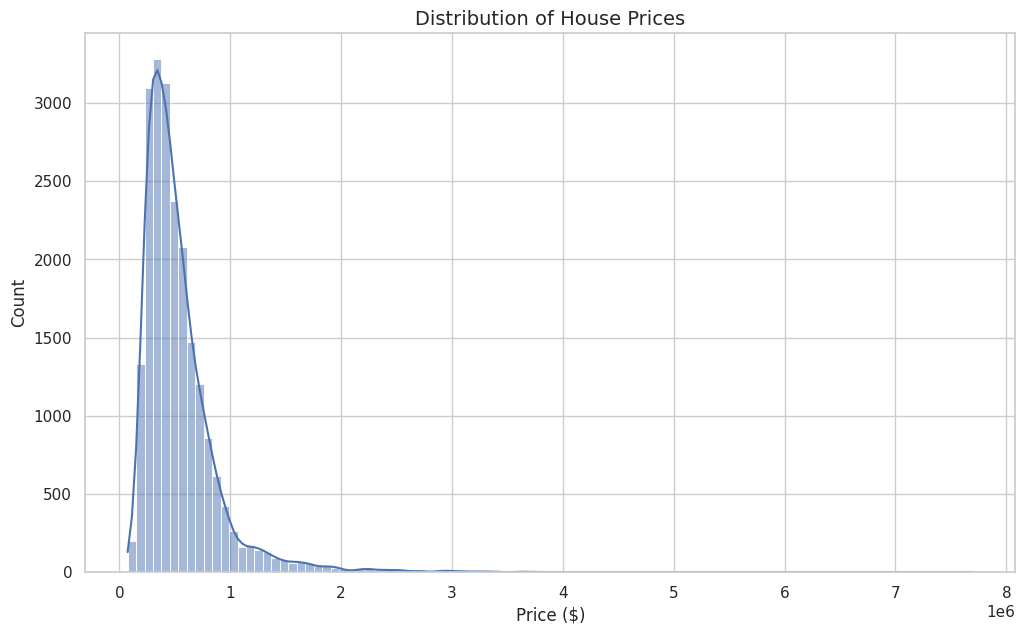

In [45]:
# --- The distribution of the house price

sns.histplot(df["price"], bins=100, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

 The price distribution is VERY right skewed. Is it the only one?

In [46]:
# --- Skewness of all the numerical variables

skewness = df.select_dtypes(include=["number"]).skew()
print(skewness)

price                    4.025637
bedrooms                 0.523205
bathrooms                0.512775
sqft_living              1.471796
sqft_lot                13.059567
floors                   0.615011
waterfront              11.384569
view                     3.396579
condition                1.032662
grade                    0.769923
sqft_above               1.446475
sqft_basement            1.577831
yr_built                -0.469656
yr_renovated             4.549253
lat                     -0.485124
long                     0.885120
sqft_living15            1.107018
sqft_lot15               9.506856
sale_year                0.757153
sale_month               0.063077
days_since_start         0.178963
ratio_living_size15      2.034814
ratio_lot_size15        31.852611
living_lot_ratio         2.375764
volume                   1.747585
was_renovated            4.548786
has_basement             0.439397
bath_per_bed             0.791726
basement_ratio           0.913801
age           

 A LOT OF numeric variables are right skewed

In [47]:
# --- log transformation
# Instead of blindly logging every skewed feature, we apply a log transform ONLY
# when it actually INCREASES the absolute Pearson correlation with the target
# ("log_price"). The decision is made on TRAINING rows only.

# The target is ALWAYS log-transformed ("log_price")
df["log_price"] = np.log(df["price"])
print(f"The skewness of 'log_price' is: {df['log_price'].skew():.4f}")

# Candidate features: an explicit WHITELIST of continuous, positive, ratio-scale
# measurement features (sizes, distances, ratios, volumes, age). Log-transforming
# probabilities (gmm_prob_*), ordinal/discrete codes (condition, view, grade...)
# or coordinates makes no semantic sense, so they are never considered.
continuous_positive_features = [
    "sqft_living", "sqft_lot", "sqft_above", "sqft_basement",
    "sqft_living15", "sqft_lot15",
    "ratio_living_size15", "ratio_lot_size15", "living_lot_ratio",
    "volume", "age",
    "dist_to_center", "dist_to_medina", "dist_to_kirkland",
    "dist_to_bellevue", "dist_to_redmond", "dist_to_issaquah",
    "dist_to_renton", "dist_to_kent", "dist_to_seatac",
    "dist_to_nearest_city",
]

candidate_cols = [col for col in continuous_positive_features
                  if col in df.columns and col != "price" and skewness.get(col, 0) > 1]

y_train_series = df.loc[train_idx, "log_price"]
comparison_rows = []

for col in candidate_cols:
    # log1p for columns that contain zeros or negatives, plain log otherwise
    func = np.log1p if (df[col] <= 0).any() else np.log

    x_tr = df.loc[train_idx, col]
    corr_raw = abs(np.corrcoef(x_tr, y_train_series)[0, 1])
    corr_log = abs(np.corrcoef(func(x_tr), y_train_series)[0, 1])

    comparison_rows.append({
        "feature": col,
        "skewness": skewness[col],
        "|corr| raw": corr_raw,
        "|corr| log": corr_log,
        "improvement": corr_log - corr_raw,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("improvement", ascending=False)

# Apply the log ONLY where it helps the linear correlation with the target
log_transformations = comparison_df.loc[comparison_df["improvement"] > 0, "feature"].tolist()

for col in log_transformations:
    func = np.log1p if (df[col] <= 0).any() else np.log
    df[f"log_{col}"] = func(df[col])
    print(f"The skewness of 'log_{col}' is: {df[f'log_{col}'].skew():.4f}")

print(f"Log-transformed ({len(log_transformations)}): {log_transformations}")
not_transformed = [col for col in candidate_cols if col not in log_transformations]
print(f"Left as-is ({len(not_transformed)}): {not_transformed}")

comparison_df

The skewness of 'log_price' is: 0.4282
The skewness of 'log_dist_to_medina' is: -0.7758
The skewness of 'log_sqft_lot' is: 0.9623
The skewness of 'log_dist_to_bellevue' is: -0.8493
The skewness of 'log_ratio_lot_size15' is: 1.6713
The skewness of 'log_sqft_lot15' is: 0.9667
The skewness of 'log_ratio_living_size15' is: 0.0204
The skewness of 'log_living_lot_ratio' is: -0.9689
Log-transformed (7): ['dist_to_medina', 'sqft_lot', 'dist_to_bellevue', 'ratio_lot_size15', 'sqft_lot15', 'ratio_living_size15', 'living_lot_ratio']
Left as-is (6): ['sqft_living', 'sqft_above', 'sqft_basement', 'sqft_living15', 'volume', 'dist_to_nearest_city']


,feature,skewness,|corr| raw,|corr| log,improvement
10,dist_to_medina,1.075937,0.498746,0.548491,0.049745
1,sqft_lot,13.059567,0.096967,0.133472,0.036505
11,dist_to_bellevue,1.047397,0.504873,0.537489,0.032616
7,ratio_lot_size15,31.852611,0.038262,0.066094,0.027832
5,sqft_lot15,9.506856,0.094080,0.119614,0.025534
6,ratio_living_size15,2.034814,0.299600,0.303667,0.004067
8,living_lot_ratio,2.375764,0.188756,0.190810,0.002054
9,volume,1.747585,0.620332,0.611823,-0.008510
4,sqft_living15,1.107018,0.615067,0.603315,-0.011752
12,dist_to_nearest_city,2.059067,0.253530,0.240710,-0.012821


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


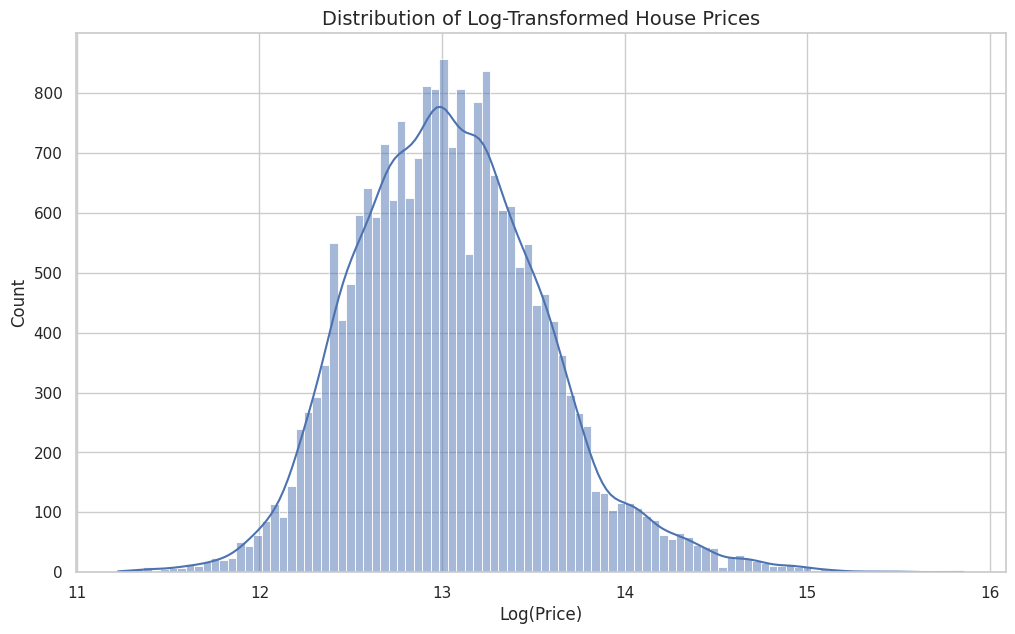

In [48]:
# Log-price distribution
sns.histplot(df["log_price"], bins=100, kde=True)
plt.title("Distribution of Log-Transformed House Prices")
plt.xlabel("Log(Price)")
plt.ylabel("Count")
plt.show()

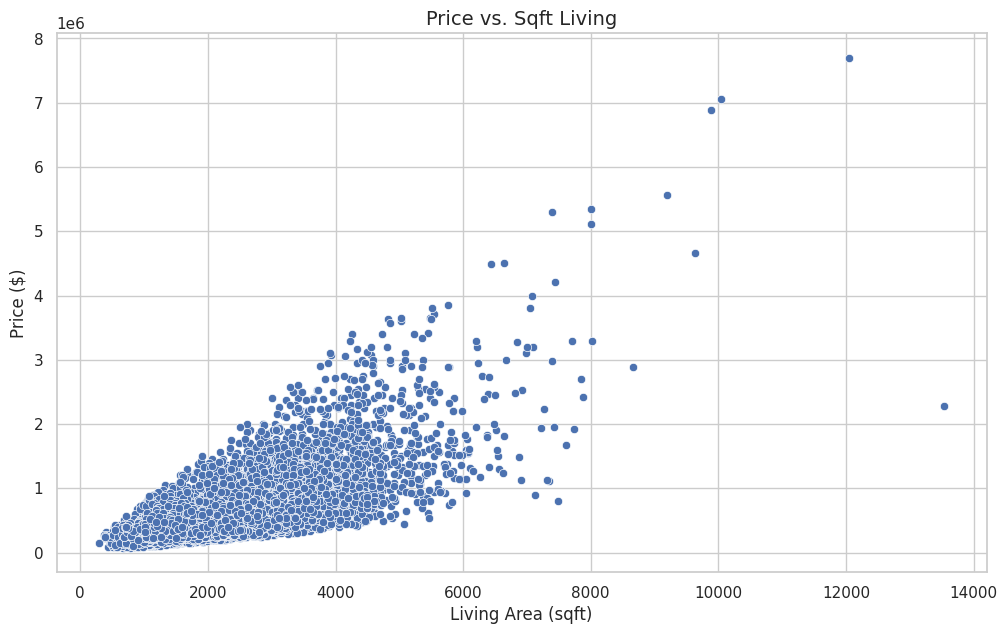

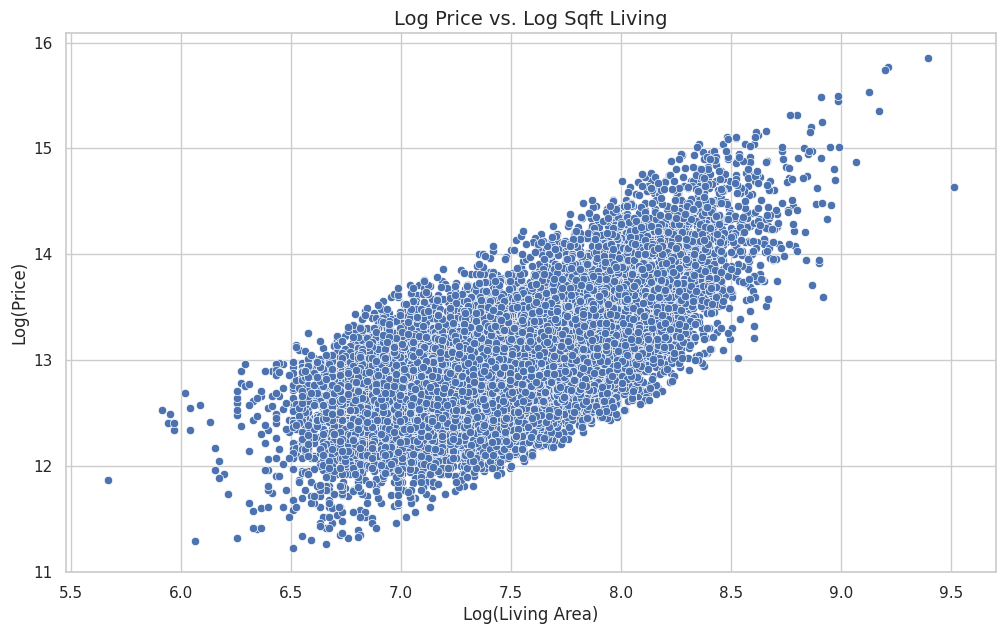

In [49]:
# Price vs sqft-living & Log-price vs log-sqft-living
# The log version is computed on the fly for visualization, regardless of whether
# the correlation analysis kept the transformation for "sqft_living".
sns.scatterplot(data=df, x="sqft_living", y="price")
plt.title("Price vs. Sqft Living")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price ($)")
plt.show()

sns.scatterplot(x=np.log(df["sqft_living"]), y=df["log_price"])
plt.title("Log Price vs. Log Sqft Living")
plt.xlabel("Log(Living Area)")
plt.ylabel("Log(Price)")
plt.show()

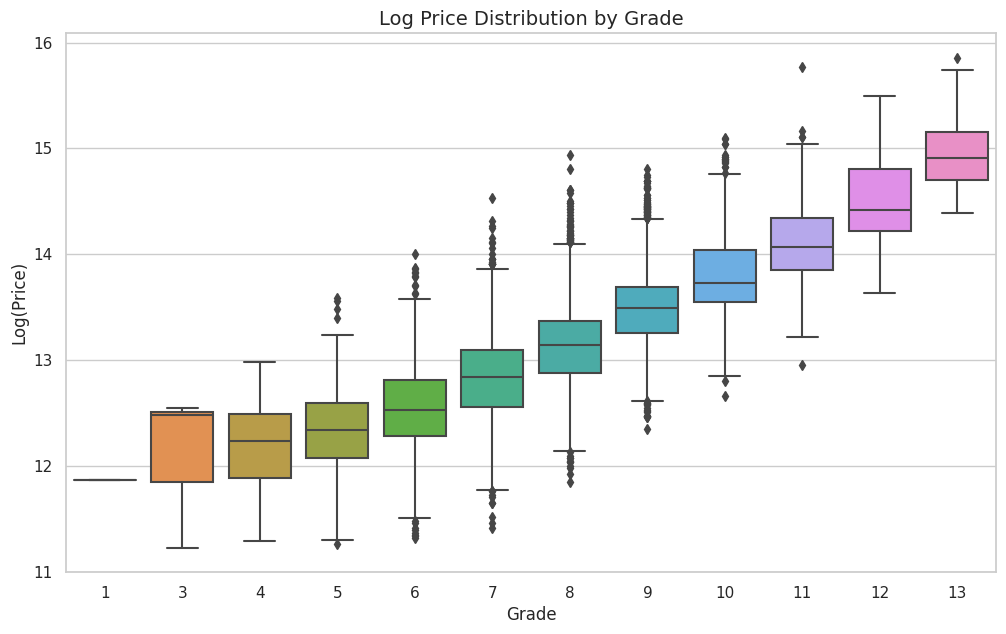

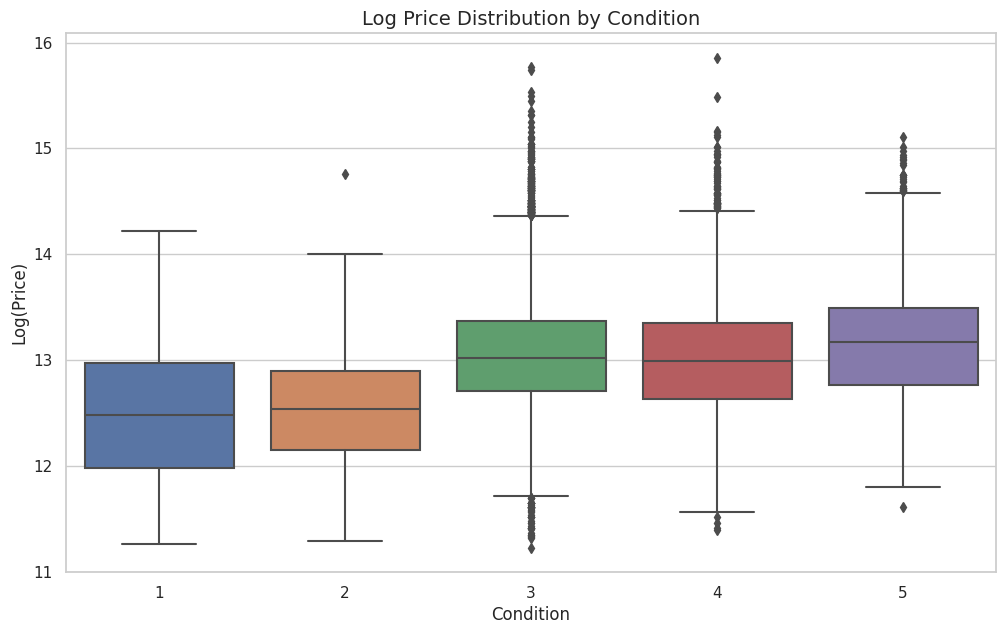

In [50]:
# --- Other cool graphs

sns.boxplot(data=df, x="grade", y="log_price")
plt.title("Log Price Distribution by Grade")
plt.xlabel("Grade")
plt.ylabel("Log(Price)")
plt.show()

sns.boxplot(data=df, x="condition", y="log_price")
plt.title("Log Price Distribution by Condition")
plt.xlabel("Condition")
plt.ylabel("Log(Price)")
plt.show()

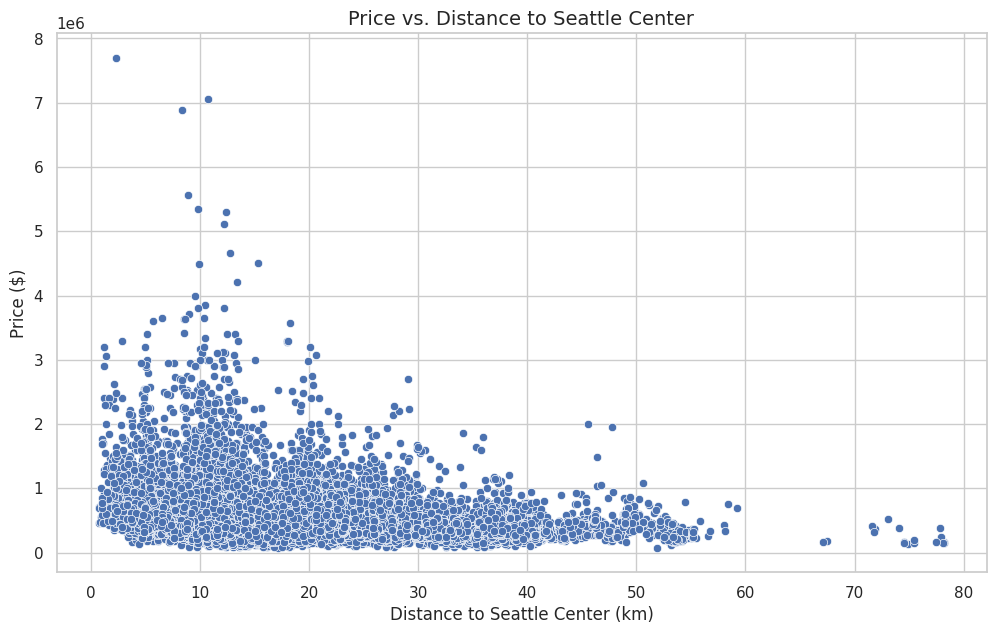

In [51]:
# --- Price vs dist_to_center

sns.scatterplot(data=df, x="dist_to_center", y="price")
plt.title("Price vs. Distance to Seattle Center")
plt.xlabel("Distance to Seattle Center (km)")
plt.ylabel("Price ($)")
plt.show()

 # Preparation to ML

In [52]:
# --- Declaration of our dependent variable (y) and removal of redundant feature versions
# For each transformed feature we keep ONLY the version chosen by the correlation
# analysis: the "log_" one when it was transformed, the raw one otherwise.

y = df["log_price"]
X = df.drop(columns=["price", "log_price"] + log_transformations)

In [53]:
# --- Train & Test. The test has 30% of the whole data
# We reuse the SAME train/test index partition defined BEFORE clustering,
# so the clusterers were fit exclusively on the training houses (no leakage).

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((15127, 60), (6484, 60), (15127,), (6484,))

In [54]:
X_train.T

,21349,17896,9100,6661,21111,3373,753,1419,12276,2255,...,14425,4427,16852,6266,11286,11966,21577,5391,860,15797
bedrooms,3,2,4,3,5,4,2,3,3,3,...,3,2,3,4,2,4,4,3,1,4
bathrooms,2.25,1.0,1.5,1.5,3.5,3.0,2.5,1.5,1.0,1.75,...,2.5,1.0,1.5,1.75,2.5,2.0,3.25,2.5,0.75,2.5
sqft_living,1720,700,1470,1180,2760,3150,2380,1430,1520,1600,...,2010,1100,1580,1680,1420,2100,1900,1990,380,2550
floors,2.0,1.0,1.0,1.0,2.5,2.0,1.0,1.0,1.0,1.0,...,2.0,1.0,1.5,2.0,2.0,1.0,2.0,1.5,1.0,1.0
waterfront,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
view,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
condition,3,3,4,3,3,3,3,3,4,3,...,3,3,5,3,3,5,3,4,3,3
grade,9,6,7,6,8,9,8,7,6,8,...,8,7,7,8,7,7,9,8,5,8
sqft_above,1240,700,810,1180,2760,3150,2380,1130,1520,1600,...,1390,620,1180,1680,1420,1060,1250,1410,380,1750
sqft_basement,480,0,660,0,0,0,0,300,0,0,...,620,480,400,0,0,1040,650,580,0,800


In [55]:
# --- Optional: save the data to Google Drive
# joblib.dump(X_train, "/content/drive/My Drive/X_train.joblib")
# joblib.dump(X_test, "/content/drive/My Drive/X_test.joblib")
# joblib.dump(y_train, "/content/drive/My Drive/y_train.joblib")
# joblib.dump(y_test, "/content/drive/My Drive/y_test.joblib")

print("Data kept in memory.")

Data kept in memory.


 ## Save / Load Data (Optional)

In [56]:
# --- Optional: load the data from Google Drive
# X_train = joblib.load("/content/drive/My Drive/X_train.joblib")
# X_test = joblib.load("/content/drive/My Drive/X_test.joblib")
# y_train = joblib.load("/content/drive/My Drive/y_train.joblib")
# y_test = joblib.load("/content/drive/My Drive/y_test.joblib")

print("Data kept in memory.")

Data kept in memory.


In [57]:
# --- Define each feature category

categorical_features_target = ["zipcode"]                                       # Define the variable "Target Encoding"
categorical_features_onehot = ["season", "hdbscan_cluster"]                     # Define the variables "One-hot Encoding"

categorical_features = categorical_features_target + categorical_features_onehot  # "Union" of TE and One-hot

numeric_features = [col for col in X_train.columns
                    if col not in categorical_features]                         # Numeric features (all the features that are not "categorical"...)

print(f"{len(numeric_features)} numeric features")

57 numeric features


In [58]:
# --- Preprocessors to be applied:
# 1. standardization (mean=0 & var=1) of the numeric features
# 2. Target encoding
# 3. One-Hot Encoding

# for ElasticNet (handles multicollinearity) -> linear model
preprocessor_elastic = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat_target", ce.TargetEncoder(), categorical_features_target),
        ("cat_onehot", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features_onehot)     # drop="first" to avoid multicollinearity in linear model
    ],
    remainder="passthrough"
)

# for RFECV -> non-linear models
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat_target", ce.TargetEncoder(), categorical_features_target),
        ("cat_onehot", OneHotEncoder(handle_unknown="ignore"), categorical_features_onehot)
    ],
    remainder="passthrough"
)

 # Linear Model (Baseline)

 ## Feature selection + Linear Regression

In [59]:
# --- Declaration key for the dictionary

run_key_linear = "LinearRegression_ElasticNetCV"

In [60]:
# --- Prepare ElasticNet as the feature selector.
# ElasticNetCV automatically chooses the best alpha AND l1_ratio.

# l1_ratios to test: L1=1 -> L1 penalty ||| L1=0 -> L2 penalty
l1_ratios_to_test = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

elastic_net_cv = ElasticNetCV(l1_ratio=l1_ratios_to_test,
                              cv=5,
                              random_state=42,
                              n_jobs=-1)

In [61]:
# --- Linear Pipeline:
# 1. apply the preprocessor_elastic to the data
# 2. perform feature selection through ElasticNetCV
# 3. train linear regression

pipeline_en = Pipeline([
    ("preprocessor", preprocessor_elastic),
    ("feature_selection", SelectFromModel(estimator=elastic_net_cv,
                                          threshold="median")),                 # Select features whose absolute coefficient is above the median
    ("regressor", LinearRegression())
])

pipeline_en.named_steps

{'preprocessor': ColumnTransformer(remainder='passthrough',
                   transformers=[('num', StandardScaler(),
                                  ['bedrooms', 'bathrooms', 'sqft_living',
                                   'floors', 'waterfront', 'view', 'condition',
                                   'grade', 'sqft_above', 'sqft_basement',
                                   'yr_built', 'yr_renovated', 'lat', 'long',
                                   'sqft_living15', 'sale_year', 'sale_month',
                                   'days_since_start', 'volume', 'was_renovated',
                                   'has_basement', 'bath_per_bed',
                                   'basement_ratio', 'age', 'dist_to_center',
                                   'dist_to_kirkland', 'dist_to_redmond',
                                   'dist_to_issaquah', 'dist_to_renton',
                                   'dist_to_kent', ...]),
                                 ('cat_target', TargetEncoder(

In [62]:
# --- Training & Storing linear model

print(f"--- Training and evaluating '{run_key_linear}' ---")

scores = cross_val_score(
    pipeline_en, X_train, y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print(f"Cross-validation MAE: {-scores.mean():.4f}")
print("Fitting the final model on the full training data...")

pipeline_en.fit(X_train, y_train)
fitted_elastic_net = pipeline_en.named_steps["feature_selection"].estimator_
linear_params = {'alpha': fitted_elastic_net.alpha_, 'l1_ratio': fitted_elastic_net.l1_ratio_}

model_results[run_key_linear] = {
    "best_score": scores.mean(),
    "best_params": linear_params,
    "best_estimator": pipeline_en,
    "cv_results_df": None
}

print(f"'{run_key_linear}' trained & results stored in memory.")

--- Training and evaluating 'LinearRegression_ElasticNetCV' ---


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.699e-01, tolerance: 3.291e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.502e-01, tolerance: 3.329e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.349e-01, tolerance: 3.327e

Cross-validation MAE: 0.1292
Fitting the final model on the full training data...
'LinearRegression_ElasticNetCV' trained & results stored in memory.


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.881e-01, tolerance: 4.153e-01


In [63]:
# --- Chosen l1 & alpha

# Load dictionary
linear_result_dict = model_results[run_key_linear]

# Get the FITTED pipeline from the dictionary
fitted_pipeline = linear_result_dict['best_estimator']

# Estimator of elasticnet
fitted_elastic_net = fitted_pipeline.named_steps["feature_selection"].estimator_

elastic_l1_ratio = fitted_elastic_net.l1_ratio_
elastic_alpha = fitted_elastic_net.alpha_

print("Chosen alpha:", elastic_alpha)
print("Chosen L1 Ratio:", elastic_l1_ratio)

Chosen alpha: 0.0003657384776059615
Chosen L1 Ratio: 1.0


 ElasticNetCV determined through cv that the best possible model was the one with l1_ratio=1.0. This means that a pure Lasso penalty was better than any mix of L1 and L2 penalties.

In [64]:
# --- All coefficients from ElasticNetCV

# Fitted ElasticNet model (the feature selector)
elastic_model = fitted_pipeline.named_steps['feature_selection'].estimator_

# Feature names AFTER the preprocessor
feature_names = fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Put them together in a Series
feature_coef = pd.Series(elastic_model.coef_, index=feature_names)

# Sort by absolute value to see the most impactful features
print("Coefficients sorted by absolute value:")
print(feature_coef.abs().sort_values(ascending=False))

Coefficients sorted by absolute value:
num__log_sqft_lot                0.356469
cat_target__zipcode              0.346947
num__log_living_lot_ratio        0.300873
num__dist_to_center              0.279696
num__dist_to_renton              0.171417
                                   ...   
num__log_sqft_lot15              0.000000
num__log_dist_to_bellevue        0.000000
num__gmm_prob_9                  0.000000
num__gmm_prob_13                 0.000000
cat_onehot__hdbscan_cluster_9    0.000000
Length: 71, dtype: float64


In [65]:
# --- Feature selected by ElasticNetCV

mask = fitted_pipeline.named_steps["feature_selection"].get_support()           # get_support() -> boolean array (True = feature selected, False otherwise)

selected_cols = np.array(feature_names)[mask]                                   # Filter features by the boolean mask

print("Selected features:", selected_cols)

Selected features: ['num__bedrooms' 'num__bathrooms' 'num__floors' 'num__waterfront'
 'num__view' 'num__condition' 'num__grade' 'num__sqft_above'
 'num__yr_renovated' 'num__lat' 'num__long' 'num__sqft_living15'
 'num__days_since_start' 'num__volume' 'num__has_basement'
 'num__basement_ratio' 'num__dist_to_center' 'num__dist_to_kirkland'
 'num__dist_to_redmond' 'num__dist_to_issaquah' 'num__dist_to_renton'
 'num__dist_to_nearest_city' 'num__gmm_prob_8' 'num__gmm_prob_11'
 'num__log_dist_to_medina' 'num__log_sqft_lot'
 'num__log_ratio_living_size15' 'num__log_living_lot_ratio'
 'cat_target__zipcode' 'cat_onehot__season_Spring'
 'cat_onehot__season_Summer' 'cat_onehot__hdbscan_cluster_2'
 'cat_onehot__hdbscan_cluster_4' 'cat_onehot__hdbscan_cluster_6'
 'cat_onehot__hdbscan_cluster_7' 'cat_onehot__hdbscan_cluster_8']


In [66]:
# --- Linear Regression coefficients

# Linear regression coefficients
linear_coefs = fitted_pipeline.named_steps['regressor'].coef_

# Series: selected features + coefficients
results_series = pd.Series(linear_coefs, index=selected_cols)

print("--- Linear Regression Model: ---")
print(results_series.sort_values(ascending=False))

--- Linear Regression Model: ---
num__log_sqft_lot                0.514349
num__log_living_lot_ratio        0.448004
cat_target__zipcode              0.350749
num__dist_to_renton              0.189038
num__grade                       0.093388
num__long                        0.080768
num__dist_to_redmond             0.071862
num__view                        0.045977
num__waterfront                  0.043188
num__volume                      0.042508
num__condition                   0.038016
cat_onehot__season_Spring        0.034038
num__dist_to_kirkland            0.028689
num__bathrooms                   0.028112
cat_onehot__season_Summer        0.027611
cat_onehot__hdbscan_cluster_7    0.026080
num__days_since_start            0.025270
num__sqft_above                  0.020240
num__yr_renovated                0.014899
num__has_basement                0.011959
cat_onehot__hdbscan_cluster_4    0.007798
cat_onehot__hdbscan_cluster_8   -0.006539
num__gmm_prob_8                 -0.011151
n

 # Non-Linear models

 In this section RFECV feature selection will be applied through a random forest. The features that will be selected by this procedure will be used to train non-linear models:





 *   Random Forest

 *   HistGradientBoosting

 *   XGBoost

 *   LightGBM

 *   NNMLP

 *   Stacking model

 ## Wrap feature selection (FS) with random forest

In [67]:
# --- CV that will be used throughout FS

cv_splitter = KFold(n_splits=5,
                    shuffle=True,
                    random_state=42)

In [68]:
# --- RFECV selector -> iteratively removes features and evaluates model performance using cv

rfecv = RFECV(
    estimator=RandomForestRegressor(                                            # Random Forest will be used as estimator
                                    n_estimators=50,                            # Number of RF trees
                                    random_state=42,
                                    n_jobs=-1),
    cv=cv_splitter,                                                             # CV defined before
    scoring="neg_mean_absolute_error",                                          # Max negative MAE = min MAE
    verbose=1,
    step=1,                                                                     # Number of features removed each time
    min_features_to_select=5,                                                   # Min number of features rfecv will retain
    importance_getter="auto",                                                   # "auto" -> feature importance for tree-based models
    n_jobs=-1
)

In [69]:
# --- Feature selection pipeline:
# 1. apply preprocessor_rf to data
# 2. perform feature selection through rfecv

pipeline_rfe = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("feature_selector", rfecv)
])

pipeline_rfe.named_steps

{'preprocessor': ColumnTransformer(remainder='passthrough',
                   transformers=[('num', StandardScaler(),
                                  ['bedrooms', 'bathrooms', 'sqft_living',
                                   'floors', 'waterfront', 'view', 'condition',
                                   'grade', 'sqft_above', 'sqft_basement',
                                   'yr_built', 'yr_renovated', 'lat', 'long',
                                   'sqft_living15', 'sale_year', 'sale_month',
                                   'days_since_start', 'volume', 'was_renovated',
                                   'has_basement', 'bath_per_bed',
                                   'basement_ratio', 'age', 'dist_to_center',
                                   'dist_to_kirkland', 'dist_to_redmond',
                                   'dist_to_issaquah', 'dist_to_renton',
                                   'dist_to_kent', ...]),
                                 ('cat_target', TargetEncoder(

In [70]:
# --- RFECV training

pipeline_rfe.fit(X_train, y_train)

Fitting estimator with 73 features.
Fitting estimator with 72 features.
Fitting estimator with 71 features.
Fitting estimator with 70 features.
Fitting estimator with 69 features.
Fitting estimator with 68 features.
Fitting estimator with 67 features.
Fitting estimator with 66 features.
Fitting estimator with 65 features.
Fitting estimator with 64 features.
Fitting estimator with 63 features.
Fitting estimator with 62 features.
Fitting estimator with 61 features.
Fitting estimator with 60 features.
Fitting estimator with 59 features.
Fitting estimator with 58 features.
Fitting estimator with 57 features.
Fitting estimator with 56 features.
Fitting estimator with 55 features.
Fitting estimator with 54 features.
Fitting estimator with 53 features.
Fitting estimator with 52 features.
Fitting estimator with 51 features.
Fitting estimator with 50 features.
Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 fe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'floors',
                                                   'waterfront', 'view',
                                                   'condition', 'grade',
                                                   'sqft_above',
                                                   'sqft_basement', 'yr_built',
                                                   'yr_renovated', 'lat',
                                                   'long', 'sqft_living15',
                                                   'sale_year', 'sale_month',
                                                   'days_since_start', 'volume',
                                                   'was_renovated...
                                                 ('cat_target', TargetEncoder(),
                                                  ['zipcode']),
                                                 ('cat_onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['season',
                                                   'hdbscan_cluster'])])),
                ('feature_selector',
                 RFECV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=RandomForestRegressor(n_estimators=50,
                                                       n_jobs=-1,
                                                       random_state=42),
                       min_features_to_select=5, n_jobs=-1,
                       scoring='neg_mean_absolute_error', verbose=1))])

In [71]:
# --- Save pipeline

#joblib.dump(pipeline_rfe, "/content/drive/My Drive/pipelineRFE.joblib")
#print("pipelineRFE.joblib saved successfully.")

In [72]:
# --- Key variables

selector = pipeline_rfe.named_steps['feature_selector']
all_feature_names = pipeline_rfe.named_steps['preprocessor'].get_feature_names_out()

In [73]:
# --- Get the final trained estimator and its importances

final_rf_model = selector.estimator_

# Get the names of ONLY the selected features
selected_features_mask = selector.support_                                      # Names of ONLY the selected features (boolean)
selected_feature_names = np.array(all_feature_names)[selected_features_mask]    # Selected features

importances = final_rf_model.feature_importances_                               # Importance scores from the final model

final_importance_df = pd.DataFrame({                                            # Create a DataFrame of the final model importance
    'Feature': selected_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

optimal_n_features_rfecv = selector.n_features_                                 # Optimal number

print(f"Optimal number of features (RFECV): {optimal_n_features_rfecv}")
print("--- Feature Importances of the FINAL Model ---")
print("(Based only on the selected features)")
print(final_importance_df.to_string())

Optimal number of features (RFECV): 33
--- Feature Importances of the FINAL Model ---
(Based only on the selected features)
                         Feature  Importance
32           cat_target__zipcode    0.430492
0               num__sqft_living    0.260646
4                     num__grade    0.087083
15           num__dist_to_center    0.032871
9             num__sqft_living15    0.015205
2                      num__view    0.012313
7                       num__lat    0.010954
24               num__gmm_prob_2    0.010395
20             num__dist_to_kent    0.010009
5                num__sqft_above    0.008410
12                   num__volume    0.008288
8                      num__long    0.007756
25       num__log_dist_to_medina    0.007107
11         num__days_since_start    0.007098
26             num__log_sqft_lot    0.006954
1                num__waterfront    0.006328
18         num__dist_to_issaquah    0.006145
29           num__log_sqft_lot15    0.005800
14                   

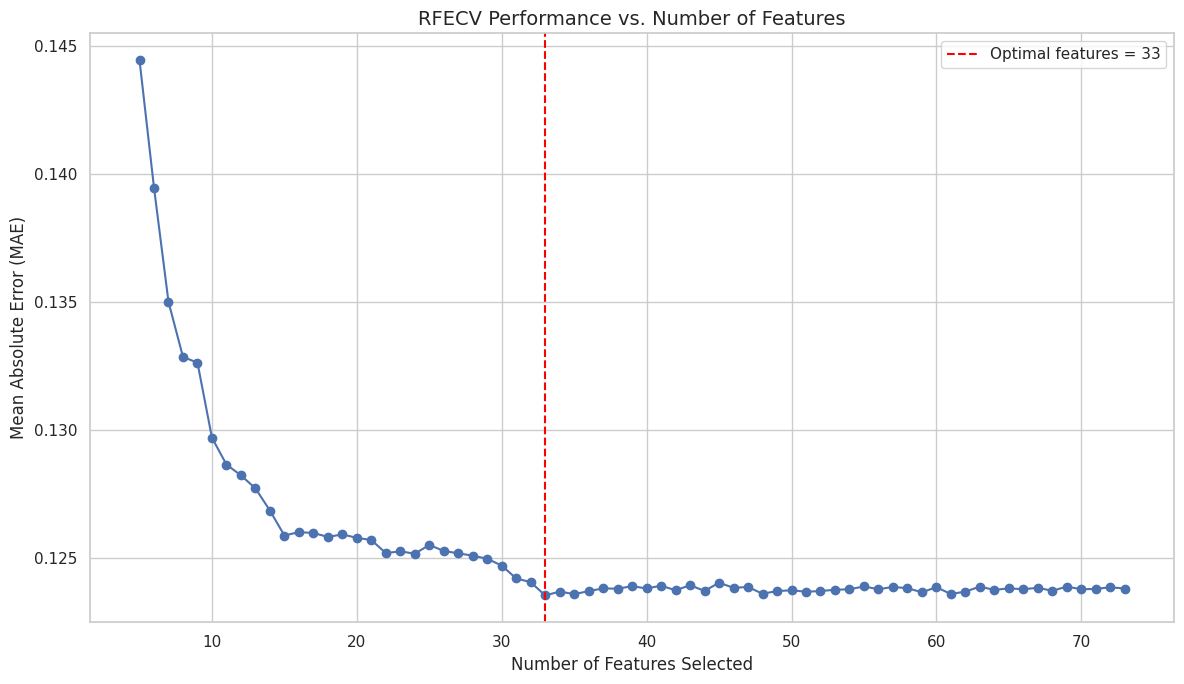

In [74]:
# --- Plot

n_scores = len(rfecv.cv_results_['mean_test_score'])
features_range = range(rfecv.min_features_to_select, rfecv.min_features_to_select + n_scores)

plt.plot(features_range, -rfecv.cv_results_['mean_test_score'], marker='o')

# Add red line
plt.axvline(x=optimal_n_features_rfecv, color='red', linestyle='--', label=f'Optimal features = {optimal_n_features_rfecv}')

# Add labels and title
plt.xlabel("Number of Features Selected")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("RFECV Performance vs. Number of Features")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

 ### One Standard-Error Rule

 Select a simpler model that performs statistically as well as the "best" model found by RFECV. This approach is based on the principle of parsimony (or Occam's Razor): if multiple models have comparable performance, we should prefer the simplest one. A simpler model is often more robust, faster, and less likely to be overfit to the training data.



 The process is as follows:









 1.   Find the best score achieved during cross-validation.

 2.   Calculate the standard error at that point.

 3.   Set a performance threshold: Best Score - 1 Standard Error.

 4.   Select the model with the fewest features that still has a score under/above this threshold.

In [75]:
# --- "One Standard Error Rule" for parsimonious FS

mean_scores = selector.cv_results_["mean_test_score"]                           # Extract mean cv scores for each number of features
std_errs = selector.cv_results_["std_test_score"] / np.sqrt(selector.cv.get_n_splits())  # Standard error of the mean score
best_idx = np.argmax(mean_scores)                                               # Index of the best mean cv score
best_score = mean_scores[best_idx]                                              # Best mean cv score

one_se_threshold = best_score - std_errs[best_idx]                              # "One standard error" threshold -> the best score minus one standard error

In [76]:
# --- Find "One-se-error" number of features

# This identifies the most parsimonious model that is still within one standard error of the best
parsimonious_idx = np.where(mean_scores >= one_se_threshold)[0][0]
parsimonious_n_features = parsimonious_idx + selector.min_features_to_select    # Index + the minimum number of features (5)

In [77]:
# --- Results of FS

print(f"Optimal number of features found by RFECV: {optimal_n_features_rfecv}")
print(f"Best cv score (MAE): {-best_score:.4f}")
print("--- Applying the 'One Standard Error' Rule ---")
print(f"Threshold (Best Score - 1 SE): {-one_se_threshold:.4f}")
print(f"The most parsimonious model with a statistically comparable score has {parsimonious_n_features} features.")

Optimal number of features found by RFECV: 33
Best cv score (MAE): 0.1236
--- Applying the 'One Standard Error' Rule ---
Threshold (Best Score - 1 SE): 0.1245
The most parsimonious model with a statistically comparable score has 31 features.


In [78]:
# --- List of parsimonious features

parsimonious_features = final_importance_df['Feature'].head(parsimonious_n_features).to_numpy()
print(f"Selected the {len(parsimonious_features)} most important parsimonious features:")
print(final_importance_df.head(parsimonious_n_features))

Selected the 31 most important parsimonious features:
                         Feature  Importance
32           cat_target__zipcode    0.430492
0               num__sqft_living    0.260646
4                     num__grade    0.087083
15           num__dist_to_center    0.032871
9             num__sqft_living15    0.015205
2                      num__view    0.012313
7                       num__lat    0.010954
24               num__gmm_prob_2    0.010395
20             num__dist_to_kent    0.010009
5                num__sqft_above    0.008410
12                   num__volume    0.008288
8                      num__long    0.007756
25       num__log_dist_to_medina    0.007107
11         num__days_since_start    0.007098
26             num__log_sqft_lot    0.006954
1                num__waterfront    0.006328
18         num__dist_to_issaquah    0.006145
29           num__log_sqft_lot15    0.005800
14                      num__age    0.005703
28     num__log_ratio_lot_size15    0.005647
6

In [79]:
# --- Save parsimonious features

#joblib.dump(parsimonious_features, "/content/drive/My Drive/parsimonious_features.joblib")
print("Parsimonious features kept in memory.")

Parsimonious features kept in memory.


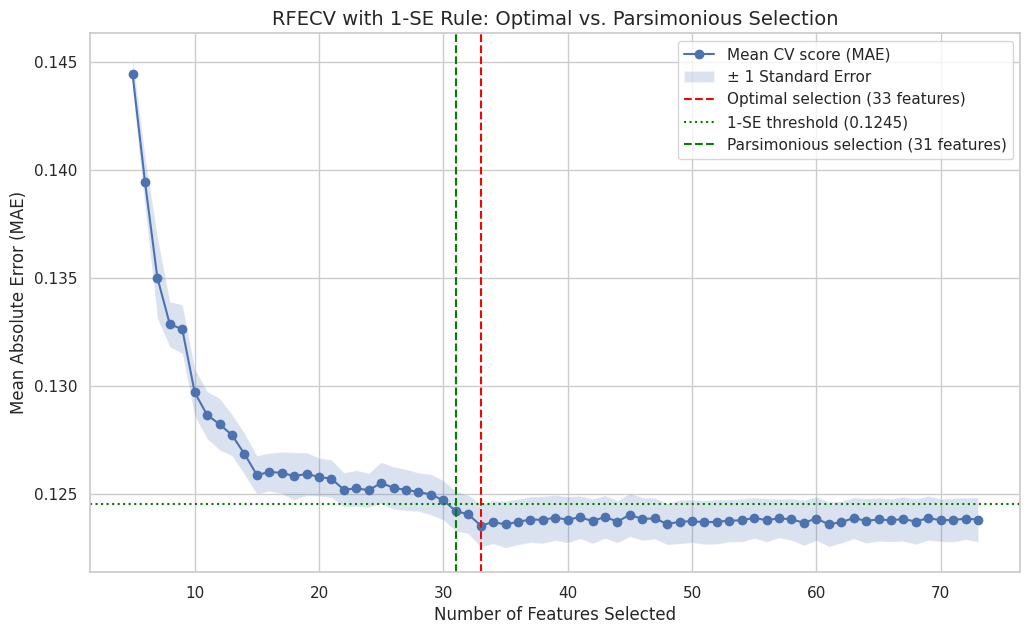

In [80]:
# --- Plot the results
plt.plot(features_range, -mean_scores, marker="o", label="Mean CV score (MAE)")

# Plot the 1-SE band around the best score
plt.fill_between(features_range, -(mean_scores - std_errs), -(mean_scores + std_errs), alpha=0.2, label="± 1 Standard Error")

# Plot the lines for different feature counts
plt.axvline(x=optimal_n_features_rfecv, color="red", linestyle="--", label=f"Optimal selection ({optimal_n_features_rfecv} features)")
plt.axhline(y=-one_se_threshold, color="green", linestyle=":", label=f"1-SE threshold ({-one_se_threshold:.4f})")
plt.axvline(x=parsimonious_n_features, color="green", linestyle="--", label=f"Parsimonious selection ({parsimonious_n_features} features)")

# Add labels and title for clarity
plt.xlabel("Number of Features Selected")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("RFECV with 1-SE Rule: Optimal vs. Parsimonious Selection")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

 From this plot we can see, with the RED line, the optimal number of features selected by RFECV (43 features). The green line parallel to the x-axis is the 1-SE rule threshold. As we can see from the vertical green line parallel to the y-axis, the model with the fewest features that has a score below the threshold is the model with 31 features.

 ### Preparing data for non-linear training

 We are going to use the trained preprocessor from the pipeline to transform both the training and test datasets. We will then selects only the features identified by the "One Standard Error Rule".

In [81]:
# --- Extract & apply THE FITTED preprocessor to data

preprocessor_rf = pipeline_rfe.named_steps["preprocessor"]                      # Extract

X_train_processed = preprocessor_rf.transform(X_train)                          # Apply to training data
X_test_processed = preprocessor_rf.transform(X_test)                            # Apply to test data

In [82]:
# --- From NumPy arrays to DataFrame for easier FS

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

In [83]:
# --- Filter train and test to keep ONLY the selected parsimonious features

X_train_selected = X_train_processed_df[parsimonious_features]
X_test_selected = X_test_processed_df[parsimonious_features]

print("Shape of the final training data for model tuning:", X_train_selected.shape)
print("Shape of the final test data for evaluation:", X_test_selected.shape)

Shape of the final training data for model tuning: (15127, 31)
Shape of the final test data for evaluation: (6484, 31)


In [84]:
X_train_selected.T

,21349,17896,9100,6661,21111,3373,753,1419,12276,2255,...,14425,4427,16852,6266,11286,11966,21577,5391,860,15797
cat_target__zipcode,12.828891,13.153356,13.339627,12.863468,12.848492,13.540648,13.369432,12.838445,14.016460,13.562785,...,13.280288,12.908928,13.217624,12.892972,13.028199,13.552256,13.123184,12.862471,12.348202,12.504175
num__sqft_living,-0.381625,-1.499567,-0.655630,-0.973477,0.758238,1.185686,0.341750,-0.699471,-0.600829,-0.513147,...,-0.063778,-1.061158,-0.535068,-0.425466,-0.710431,0.034864,-0.184341,-0.085699,-1.850294,0.528073
num__grade,1.163440,-1.409565,-0.551897,-1.409565,0.305771,1.163440,0.305771,-0.551897,-1.409565,0.305771,...,0.305771,-0.551897,-0.551897,0.305771,-0.551897,-0.551897,1.163440,0.305771,-2.267233,0.305771
num__dist_to_center,-0.889084,-0.940248,-0.037076,2.251712,-0.047468,0.514963,0.683103,-0.562063,-0.620959,-0.445613,...,0.732614,1.630245,-0.982464,-0.132242,0.099629,-1.161234,-1.272006,2.476175,-0.314024,1.293890
num__sqft_living15,-0.376379,-1.344191,-1.006923,-0.435035,0.899372,1.456597,-0.156422,-0.713647,1.075338,0.972691,...,-0.420371,-0.273733,-0.581673,-0.200414,-0.698983,-0.083103,-0.391043,-0.464362,-1.182889,0.415466
num__view,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,...,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939,-0.305939
num__lat,-0.034625,-0.077938,1.014255,-0.516114,-0.394118,0.272170,1.136973,1.268354,0.199983,0.026734,...,-0.058447,1.539778,0.964446,-0.709576,-0.522611,0.796971,0.197817,-1.686269,-0.566645,-1.754125
num__gmm_prob_2,-0.301547,-0.301658,-0.288524,-0.301658,-0.301658,0.303487,-0.301534,-0.301658,0.076831,-0.290810,...,-0.299947,-0.301658,-0.301295,-0.301658,-0.301658,-0.282438,-0.288884,-0.301658,-0.301658,-0.301658
num__dist_to_kent,-0.442308,-0.240638,1.012099,0.951658,-0.864885,0.382029,1.388543,1.323558,-0.132572,-0.345036,...,0.118440,2.217810,0.956904,-1.067526,-1.011409,0.691239,-0.097196,0.117501,-1.024995,-1.026555
num__sqft_above,-0.655949,-1.311099,-1.177642,-0.728743,1.188177,1.661341,0.727146,-0.789405,-0.316241,-0.219182,...,-0.473963,-1.408158,-0.728743,-0.122123,-0.437565,-0.874332,-0.643816,-0.449698,-1.699336,-0.037196


In [85]:
# --- Save the processed data to Google Drive

#joblib.dump(X_train_selected, "/content/drive/My Drive/X_train_selected.joblib")
#joblib.dump(X_test_selected, "/content/drive/My Drive/X_test_selected.joblib")

#print("Data saved to Google Drive.")

 ### Load processed non-linear train & test

In [86]:
# --- Load the processed data from Google Drive

#X_train_selected = joblib.load("/content/drive/My Drive/X_train_selected.joblib")
#X_test_selected = joblib.load("/content/drive/My Drive/X_test_selected.joblib")

print("Data kept in memory.")

Data kept in memory.


 ## Model Training



 Before tuning our models, it's important to clarify my methodology. I will use the single, optimized set of features selected by RFECV as the input for all subsequent models (Random Forest, HistGradientBoosting, etc.).



 One could argue that each model should undergo its own feature selection, as different algorithms might prefer different features. However, this approach is done for several key reasons:







 *   Computational Practicality: Nesting feature selection within the hyperparameter tuning loop for every model is computationally prohibitive;

 *   Stability: A fully nested procedure can "overfit" the selection process;

 *   Simplicity: This two-step process is easier to manage and understand.



 ### Tuning control switch:

 The underlying idea is that performing precise parameter tuning right from the start and hoping to achieve a good result with a limited number of iterations is very difficult. To overcome this problem, a random search is initially performed to explore the spaces that can lead to better results. Once these are found, a more thorough search is performed within them to achieve a better result.

In [87]:
# ================================================================= #
#                   TUNING CONTROL SWITCH
# ================================================================= #

# "RANDOM" -> optuna random search ||| "OPTUNA" -> optuna type search

TUNING_STAGE = "OPTUNA"
print(f"--- RUNNING TUNING STAGE: {TUNING_STAGE} ---")

# ================================================================= #

--- RUNNING TUNING STAGE: OPTUNA ---


In [88]:
# --- CV that will be used throughout model tuning

cv_splitter_tuning = KFold(n_splits=5,
                           shuffle=True,
                           random_state=42)

In [89]:
# --- Parameter space for Non-Linear Models
# With Optuna search log=True/False -> False (Uniform Distribution): every interval of the same width is equally likely
#                                      True (Log-Uniform Distribution): every multiplicative interval is equally likely. Ideal when with parameters that cover several orders of magnitude

# IF you notice that some parameter are "#" its because I wanted to know that they exist

models_config = {
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=1),              # n_jobs=1: parallelism is handled by OptunaSearchCV (avoids thread oversubscription)
        "random_space": {
            "model__n_estimators":          od.IntDistribution(100, 2000),                      # Number of trees in the forest
            "model__max_depth":             od.IntDistribution(10, 80),                         # Max depth of each individual tree (deeper trees are prone to overfit)
            "model__min_samples_split":     od.IntDistribution(2, 50),                          # Min data required in a node for splitting (higher values -> act as regularizer)
            "model__min_samples_leaf":      od.IntDistribution(1, 20),                          # Min data that must be present in a leaf node
            "model__max_features":          od.CategoricalDistribution(["sqrt",                 # Number of features to consider when looking for the best split
                                                                        "log2"]),
        },
        "optuna_space": {
            "model__n_estimators":          od.IntDistribution(1000, 2500),
            "model__max_depth":             od.IntDistribution(10, 30),
            "model__min_samples_split":     od.IntDistribution(10, 25),
            "model__min_samples_leaf":      od.IntDistribution(2, 10),
            "model__max_features":          od.CategoricalDistribution(["sqrt"]),
        }
    },
    "HistGradientBoosting": {
        "model": HistGradientBoostingRegressor(
            random_state=42,
            loss="absolute_error",                                              # Train on MAE (aligned with the project objective)
            validation_fraction=0.1,
            n_iter_no_change=50
        ),
        "random_space": {
            "model__learning_rate":        od.FloatDistribution(0.01, 0.3, log=True),           # Step-size shrinkage. It scales the contribution of each tree
            "model__max_iter":             od.IntDistribution(100, 2000),                       # The number of boosting stages
            "model__max_leaf_nodes":       od.IntDistribution(20, 100),                         # The maximum number of leaves per tree
            "model__min_samples_leaf":     od.IntDistribution(10, 50),                          # Minimum number of samples required to be at a leaf node
            "model__l2_regularization":    od.FloatDistribution(1e-6, 1.0, log=True),           # The L2 regularization term on weights (help prevent overfit)
            "model__max_depth":            od.IntDistribution(3, 20),                           # Max depth of each tree
        },
        "optuna_space": {
            "model__learning_rate":        od.FloatDistribution(0.01, 0.1, log=True),
            "model__max_iter":             od.IntDistribution(800, 2500),
            "model__max_leaf_nodes":       od.IntDistribution(30, 80),
            "model__min_samples_leaf":     od.IntDistribution(15, 40),
            "model__l2_regularization":    od.FloatDistribution(1e-4, 1.0, log=True),
            "model__max_depth":            od.IntDistribution(8, 20),
        }
    },
    "XGBoost": {
        "model": XGBRegressor(
            random_state=42,
            objective="reg:absoluteerror",                                                       # Training metric (XGBOOST default is MSE)
            n_jobs=1                                                                             # n_jobs=1: parallelism is handled by OptunaSearchCV (avoids thread oversubscription)
        ),
        "random_space": {
            "model__learning_rate":        od.FloatDistribution(0.01, 0.3, log=True),            # Step-size shrinkage. It scales the contribution of each tree
            "model__n_estimators":         od.IntDistribution(100, 2000),                        # The number of boosting stages
            "model__max_depth":            od.IntDistribution(3, 20),                            # Max depth of each tree
            "model__min_child_weight":     od.IntDistribution(1, 20),                            # Minimum sum of instance weight needed in a child
            "model__subsample":            od.FloatDistribution(0.6, 1.0, log=False),            # Fraction of train data to be used for each tree (prevent overfit)
            "model__colsample_bytree":     od.FloatDistribution(0.6, 1.0, log=False),            # The fraction of features to be used when constructing each tree
            "model__reg_alpha":            od.FloatDistribution(1e-6, 1.0, log=True),            # L1 regularization
            "model__reg_lambda":           od.FloatDistribution(1e-6, 1.0, log=True),            # L2 regularization
        },
        "optuna_space": {
            "model__learning_rate":        od.FloatDistribution(0.01, 0.1, log=True),
            "model__n_estimators":         od.IntDistribution(800, 2500),
            "model__max_depth":            od.IntDistribution(3, 8),
            "model__min_child_weight":     od.IntDistribution(10, 30),
            "model__subsample":            od.FloatDistribution(0.6, 1.0, log=False),
            "model__colsample_bytree":     od.FloatDistribution(0.7, 1.0, log=False),
            "model__reg_alpha":            od.FloatDistribution(1e-6, 1.0, log=True),
            "model__reg_lambda":           od.FloatDistribution(1e-6, 1.0, log=True),
        },
    },
    "LightGBM": {
        "model": lgb.LGBMRegressor(
            random_state=42,
            objective="regression_l1",                                          # Train on MAE (aligned with the project objective)
            verbose=-1,
            n_jobs=1                                                                             # n_jobs=1: parallelism is handled by OptunaSearchCV (avoids thread oversubscription)
        ),
        "random_space": {
            "model__learning_rate":        od.FloatDistribution(0.01, 0.3, log=True),           # Step-size shrinkage. It scales the contribution of each tree
            "model__n_estimators":         od.IntDistribution(100, 2000),                       # The number of boosting stages
            "model__num_leaves":           od.IntDistribution(20, 100),                         # Control complexity of the tree model
            "model__min_child_samples":    od.IntDistribution(10, 50),                          # Minimum num of data needed in a child
            "model__subsample":            od.FloatDistribution(0.6, 1.0, log=False),           # Fraction of train data used for each tree (needs subsample_freq > 0 to be active)
            "model__subsample_freq":       od.IntDistribution(1, 7),                            # Bagging frequency: without it (>0) subsample would be silently ignored
            "model__colsample_bytree":     od.FloatDistribution(0.6, 1.0, log=False),           # The fraction of features to be used when constructing each tree
            "model__reg_alpha":            od.FloatDistribution(1e-6, 1.0, log=True),           # L1 regularization
            "model__reg_lambda":           od.FloatDistribution(1e-6, 1.0, log=True),           # L2 regularization
        },
        "optuna_space": {
            "model__learning_rate":        od.FloatDistribution(0.01, 0.2, log=True),
            "model__n_estimators":         od.IntDistribution(100, 1500),
            "model__num_leaves":           od.IntDistribution(20, 80),
            "model__min_child_samples":    od.IntDistribution(10, 50),
            "model__subsample":            od.FloatDistribution(0.6, 1.0, log=False),           # Needs subsample_freq > 0 to be active
            "model__subsample_freq":       od.IntDistribution(1, 7),
            "model__colsample_bytree":     od.FloatDistribution(0.6, 1.0, log=False),
            "model__reg_alpha":            od.FloatDistribution(1e-6, 1.0, log=True),
            "model__reg_lambda":           od.FloatDistribution(1e-6, 1.0, log=True),
        }
    },
    "NNMLP": {
        "model": MLPRegressor(
            random_state=42,
            max_iter=500,                                                                                           # Max epochs
            early_stopping=True                                                                                     # Stop mechanism to prevent overfit (default is if after 10 epochs no change -> stop)
        ),
        "random_space": {
            "model__hidden_layer_sizes":   od.CategoricalDistribution([(50, 25),                                    # Number of neurons in each layer: 50 first hidden, 25 second hidden
                                                                       (100, 50),                                   # 100 first hidden, 50 second hidden
                                                                       (150, 75),                                   # 150 first hidden, 75 second hidden
                                                                       (100, 50, 25),                               # 100 first hidden, 50 second hidden, 25 third hidden
                                                                       (150, 100, 50),                              # 150 first hidden, 100 second hidden, 50 third hidden
                                                                       (200, 100, 50, 25),                          # 200 first hidden, 100 second hidden, 50 third hidden, 25 fourth hidden
                                                                       (250, 150, 100, 50),                         # 250 first hidden, 150 second hidden, 100 third hidden, 50 fourth hidden
                                                                       ]),
            "model__alpha":                od.FloatDistribution(1e-5, 1.0, log=True),                               # L2 regularization
            "model__learning_rate_init":   od.FloatDistribution(1e-4, 1e-2, log=True),                              # Learning rate
            "model__activation":           od.CategoricalDistribution(["relu", "tanh"]),                            # Activation function
            "model__solver":               od.CategoricalDistribution(["adam", "sgd"]),                             # Optimizer
            "model__batch_size":           od.CategoricalDistribution([32, 64, 128]),                               # Batch size
        },
        "optuna_space": {
            "model__hidden_layer_sizes":   od.CategoricalDistribution([(100, 50),
                                                                       (150, 75),
                                                                       (150, 100, 50),
                                                                       (200, 100, 50, 25)
                                                                       ]),
            "model__alpha":                od.FloatDistribution(1e-5, 0.1, log=True),
            "model__learning_rate_init":   od.FloatDistribution(1e-4, 2e-3, log=True),
            "model__activation":           od.CategoricalDistribution(["tanh"]),
            "model__solver":               od.CategoricalDistribution(["adam"]),
            "model__batch_size":           od.CategoricalDistribution([64, 128]),
        }
    },
}

Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 25) which is of type tuple.
Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (150, 75) which is of type tuple.
Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50, 25) which is of type tuple.
Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (150, 100, 50) which is of type tuple.
Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (200, 100, 50, 25) which is of type tuple.
Choices for a cat

In [90]:
# --- Tuning & Saving Loop
# This training loop uses RANDOM/OPTUNA search (depending on the switch above)
# The for loop iterates over the model names ("RandomForest", ...) and their configs ("model", "optuna_space", "random_space")
# The first "if" is used to select the tuning strategy
# After the selection, the search starts
# A "try/except" is used to NOT stop the loop if there is any error (we don't want that if only one model fails, the whole loop stops)
# OptunaSearchCV starts
# Training starts
# The results are saved in "model_results[run_key] = {}"
# The last "except" is related to the initial "try"

# Training and Tuning Loop

for name, config in models_config.items():                              # "name" -> model's name ("RandomForest",...) ||| "config" -> model & spaces
    run_key = f"{name}_{TUNING_STAGE}"

    if TUNING_STAGE == "RANDOM":                                        # Wider exploration space...
        current_space = config["random_space"]
        n_trials = 10                                                   # ...with fewer trials
    else:                                                               # ...vs narrower space...
        current_space = config["optuna_space"]
        n_trials = 20                                                   # ...with a more intensive search

    print(f"--- Tuning {name} ---")
    pipeline = Pipeline([("model", config["model"])])                   # Pipeline with the model

    try:
        optuna_search = OptunaSearchCV(
            estimator=pipeline,
            param_distributions=current_space,                          # Parameter space
            n_trials=n_trials,                                          # Number of iterations
            cv=cv_splitter_tuning,                                      # CV
            scoring="neg_mean_absolute_error",                          # Max negative MAE = min MAE (eval metric)
            n_jobs=-1,
            random_state=42,
            verbose=1
        )

        optuna_search.fit(X_train_selected, y_train)

        # Store results in the dictionary
        model_results[run_key] = {
            "best_params": optuna_search.best_params_,
            "best_score": optuna_search.best_score_,
            "best_estimator": optuna_search.best_estimator_,
            "cv_results_df": optuna_search.trials_dataframe()
        }

        print(f"Best parameters found for {name}: {optuna_search.best_params_}")
        print(f"Best CV MAE for {name}: {-optuna_search.best_score_:.4f}")
        print(f"Successfully trained {name} and updated results in memory.")

    except Exception as e:
        print(f"!!! An error when tuning {name} !!!")
        print(f"Error: {e}")
        print("Skipping to the next model.")
        continue

print("--- All model tuning attempts are complete. ---")

OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
[I 2026-08-24 17:17:08,814] A new study created in memory with name: no-name-13076279-fc3a-4e18-9f93-65c71a9ff12a


--- Tuning RandomForest ---


[I 2026-08-24 17:22:17,135] Trial 0 finished with value: -0.12526848970569793 and parameters: {'model__n_estimators': 1171, 'model__max_depth': 20, 'model__min_samples_split': 14, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt'}. Best is trial 0 with value: -0.12526848970569793.
[I 2026-08-24 17:22:59,299] Trial 2 finished with value: -0.12528652112907088 and parameters: {'model__n_estimators': 1334, 'model__max_depth': 21, 'model__min_samples_split': 14, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt'}. Best is trial 0 with value: -0.12526848970569793.
[I 2026-08-24 17:26:13,051] Trial 3 finished with value: -0.12403957044147551 and parameters: {'model__n_estimators': 2011, 'model__max_depth': 27, 'model__min_samples_split': 10, 'model__min_samples_leaf': 8, 'model__max_features': 'sqrt'}. Best is trial 3 with value: -0.12403957044147551.
[I 2026-08-24 17:27:18,985] Trial 4 finished with value: -0.12523850289888486 and parameters: {'model__n_estimators': 1158

Best parameters found for RandomForest: {'model__n_estimators': 1049, 'model__max_depth': 19, 'model__min_samples_split': 19, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt'}
Best CV MAE for RandomForest: 0.1219
Successfully trained RandomForest and updated results in memory.
--- Tuning HistGradientBoosting ---


[I 2026-08-24 18:03:04,016] Trial 1 finished with value: -0.11007921133198537 and parameters: {'model__learning_rate': 0.03214678391431874, 'model__max_iter': 1172, 'model__max_leaf_nodes': 34, 'model__min_samples_leaf': 18, 'model__l2_regularization': 0.033517949356210955, 'model__max_depth': 16}. Best is trial 1 with value: -0.11007921133198537.
[I 2026-08-24 18:05:54,307] Trial 2 finished with value: -0.112004803055107 and parameters: {'model__learning_rate': 0.010395329115157927, 'model__max_iter': 1027, 'model__max_leaf_nodes': 53, 'model__min_samples_leaf': 35, 'model__l2_regularization': 0.032378783989872914, 'model__max_depth': 16}. Best is trial 1 with value: -0.11007921133198537.
[I 2026-08-24 18:06:00,403] Trial 0 finished with value: -0.11044761020466091 and parameters: {'model__learning_rate': 0.025017402250053247, 'model__max_iter': 1490, 'model__max_leaf_nodes': 70, 'model__min_samples_leaf': 33, 'model__l2_regularization': 0.07719956568557558, 'model__max_depth': 8}. Be

...

Best parameters found for XGBoost: {'model__learning_rate': 0.02277745046613471, 'model__n_estimators': 2448, 'model__max_depth': 7, 'model__min_child_weight': 25, 'model__subsample': 0.6048204477548994, 'model__colsample_bytree': 0.7513940743964703, 'model__reg_alpha': 0.004844060020662995, 'model__reg_lambda': 1.350782631276059e-05}
Best CV MAE for XGBoost: 0.1083
Successfully trained XGBoost and updated results in memory.
--- Tuning LightGBM ---


[I 2026-08-24 18:50:09,031] Trial 0 finished with value: -0.1098955232102005 and parameters: {'model__learning_rate': 0.026478130148162814, 'model__n_estimators': 560, 'model__num_leaves': 55, 'model__min_child_samples': 22, 'model__subsample': 0.9173078705248132, 'model__subsample_freq': 1, 'model__colsample_bytree': 0.7845569250980704, 'model__reg_alpha': 0.004987837016260528, 'model__reg_lambda': 0.0021136221258331953}. Best is trial 0 with value: -0.1098955232102005.
[I 2026-08-24 18:50:38,498] Trial 1 finished with value: -0.11063301380189801 and parameters: {'model__learning_rate': 0.0143244075592888, 'model__n_estimators': 969, 'model__num_leaves': 42, 'model__min_child_samples': 47, 'model__subsample': 0.8011632151186812, 'model__subsample_freq': 5, 'model__colsample_bytree': 0.962136745566659, 'model__reg_alpha': 0.0007618621951992168, 'model__reg_lambda': 9.838234404141971e-05}. Best is trial 0 with value: -0.1098955232102005.
[I 2026-08-24 18:50:41,366] Trial 2 finished with

Best parameters found for LightGBM: {'model__learning_rate': 0.01687908602468276, 'model__n_estimators': 1451, 'model__num_leaves': 71, 'model__min_child_samples': 19, 'model__subsample': 0.652586210810605, 'model__subsample_freq': 3, 'model__colsample_bytree': 0.6687511563736607, 'model__reg_alpha': 0.002070546161132539, 'model__reg_lambda': 0.010850768172791962}
Best CV MAE for LightGBM: 0.1083
Successfully trained LightGBM and updated results in memory.
--- Tuning NNMLP ---


[I 2026-08-24 18:59:43,481] Trial 2 finished with value: -0.12233726646427223 and parameters: {'model__hidden_layer_sizes': (150, 75), 'model__alpha': 0.010973781901657084, 'model__learning_rate_init': 0.001937917493817781, 'model__activation': 'tanh', 'model__solver': 'adam', 'model__batch_size': 64}. Best is trial 2 with value: -0.12233726646427223.
[I 2026-08-24 19:02:19,608] Trial 0 finished with value: -0.1196752736895181 and parameters: {'model__hidden_layer_sizes': (150, 75), 'model__alpha': 1.2625577795244513e-05, 'model__learning_rate_init': 0.0005577084215455658, 'model__activation': 'tanh', 'model__solver': 'adam', 'model__batch_size': 64}. Best is trial 0 with value: -0.1196752736895181.
[I 2026-08-24 19:04:21,621] Trial 4 finished with value: -0.11973411918342292 and parameters: {'model__hidden_layer_sizes': (150, 75), 'model__alpha': 0.0004107830454789824, 'model__learning_rate_init': 0.001652530287867176, 'model__activation': 'tanh', 'model__solver': 'adam', 'model__batc

Best parameters found for NNMLP: {'model__hidden_layer_sizes': (150, 75), 'model__alpha': 0.0031511865262546473, 'model__learning_rate_init': 0.0002519315435439864, 'model__activation': 'tanh', 'model__solver': 'adam', 'model__batch_size': 128}
Best CV MAE for NNMLP: 0.1190
Successfully trained NNMLP and updated results in memory.
--- All model tuning attempts are complete. ---


In [91]:
# --- Summary of non-linear training results

#model_results = joblib.load(model_results_path)

for name, result in model_results.items():
    # We add conditions to filter out the baseline and the final stacking model
    if "Linear" not in name and "Stacking" not in name:
        print(f"--- Results for {name} ---")
        # Access the dictionary keys to get the score and parameters
        print(f"Best CV MAE: {-result['best_score']:.4f}")
        print(f"Best parameters found: {result['best_params']}")

--- Results for RandomForest_OPTUNA ---
Best CV MAE: 0.1219
Best parameters found: {'model__n_estimators': 1049, 'model__max_depth': 19, 'model__min_samples_split': 19, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt'}
--- Results for HistGradientBoosting_OPTUNA ---
Best CV MAE: 0.1100
Best parameters found: {'model__learning_rate': 0.024213416282947597, 'model__max_iter': 1722, 'model__max_leaf_nodes': 43, 'model__min_samples_leaf': 22, 'model__l2_regularization': 0.015631381845654595, 'model__max_depth': 8}
--- Results for XGBoost_OPTUNA ---
Best CV MAE: 0.1083
Best parameters found: {'model__learning_rate': 0.02277745046613471, 'model__n_estimators': 2448, 'model__max_depth': 7, 'model__min_child_weight': 25, 'model__subsample': 0.6048204477548994, 'model__colsample_bytree': 0.7513940743964703, 'model__reg_alpha': 0.004844060020662995, 'model__reg_lambda': 1.350782631276059e-05}
--- Results for LightGBM_OPTUNA ---
Best CV MAE: 0.1083
Best parameters found: {'model__learni

In [92]:
# Terminate open tunnels if any
#ngrok.kill()

# Set the authtoken (get a free one from https://dashboard.ngrok.com/get-started/your-authtoken)
# Replace "PUT_HERE_YOUR_TOKEN" with your actual token
#NGROK_AUTH_TOKEN = "PUT_HERE_YOUR_TOKEN"
#ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# Get the MLflow tracking URI. In Colab, this will be a local file path. (THE RESULTS WILL BE DELETED SINCE IT IS IN COLAB)
#tracking_uri = mlflow.get_tracking_uri()

# Run the MLflow UI in the background
#get_ipython().system_raw(f"mlflow ui --backend-store-uri {tracking_uri} &")

# Open a tunnel to the MLflow UI (default port is 5000)
#public_url = ngrok.connect(5000)
print("--- MLflow UI is running! Click the link below: ---")
#print(public_url)

--- MLflow UI is running! Click the link below: ---


 ## Stacking Model



 Stacking is an ensemble learning technique where multiple different models (called base learners) are trained on the same dataset, and their predictions are then combined by a meta-model to produce the final output.



 *   Train several base models independently on the training data

 *   Collect their predictions via cross-validation

 *   Use these predictions as new features to train a meta-model

 *   For new data, each base model makes a prediction -> meta-model combines them into the final prediction.



 It’s important to use base learners that make different kinds of errors, so that the meta-model can correct them and improve generalization.



 I used Random Forest (bagging) and XGBoost (boosting) as base learners.

 Their predictions are combined by Ridge Regression, which learns the optimal weighting while controlling overfitting through regularization.

In [93]:
# --- Define stacking models for dictionary

stacking_model_name = "Stacking"

In [94]:
# --- Load result from previous tuning

#model_results = joblib.load(model_results_path)
print("Results kept in memory.")

Results kept in memory.


In [95]:
# --- XGB & RF parameters

def find_model_result(model_base_name):
    """Return the stored tuning results for a model, preferring OPTUNA over RANDOM."""
    for suffix in ("OPTUNA", "RANDOM"):
        key = f"{model_base_name}_{suffix}"
        if key in model_results:
            return model_results[key]
    raise KeyError(f"No tuned results found for '{model_base_name}'.")

rf_best_params = find_model_result("RandomForest")['best_params']
xgb_best_params = find_model_result("XGBoost")['best_params']

# Remove "model__" prefix
rf_best_params = {key.replace("model__", ""): value for key, value in rf_best_params.items()}
xgb_best_params = {key.replace("model__", ""): value for key, value in xgb_best_params.items()}

print("Optimized parameters:")
print("XGB:", xgb_best_params)
print("RF:", rf_best_params)

Optimized parameters:
XGB: {'learning_rate': 0.02277745046613471, 'n_estimators': 2448, 'max_depth': 7, 'min_child_weight': 25, 'subsample': 0.6048204477548994, 'colsample_bytree': 0.7513940743964703, 'reg_alpha': 0.004844060020662995, 'reg_lambda': 1.350782631276059e-05}
RF: {'n_estimators': 1049, 'max_depth': 19, 'min_samples_split': 19, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


In [96]:
# --- Define the Stacking Regressor
# I am creating NEW, UN-FITTED models with these best hyperparameters

base_estimators = [
    ("rf", RandomForestRegressor(**rf_best_params,
                                 random_state=42,
                                 n_jobs=1)),                            # n_jobs=1: parallelism is handled by the outer OptunaSearchCV
    ("xgb", XGBRegressor(**xgb_best_params,
                         objective="reg:absoluteerror",                         # Training metric (XGBOOST default is MSE)
                         random_state=42,
                         n_jobs=1))
]

In [97]:
# --- The Stacking Regressor with a final Ridge estimator

stacking_reg = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(),
    n_jobs=-1
)

In [98]:
# --- Search space parameters for Ridge

stacking_search_space = {
    "final_estimator__alpha": od.FloatDistribution(0.1, 10.0, log=True),        # L2 regularization
    "passthrough":            od.CategoricalDistribution([True,                 # "True"  -> Ridge has in input the predictions of RF and XGB and the original data
                                                          False]),              # "False" -> Ridge has in input ONLY the predictions of RF and XGB;
}

In [99]:
# --- Hyperparameter search for the stacking model

optuna_search_stacking = OptunaSearchCV(
    estimator=stacking_reg,
    param_distributions=stacking_search_space,
    n_trials=5,                                                                 # Fewer trials because there are 2 hyperparameters (and the computational time is very big...)
    cv=cv_splitter_tuning,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)

OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.


In [100]:
# --- RUN & SAVE STACKING !!!

print(f"--- Tuning '{stacking_model_name}' model ---")
optuna_search_stacking.fit(X_train_selected, y_train)                           # Train

# Save results in dictionary format
model_results[stacking_model_name] = {
    "best_score": optuna_search_stacking.best_score_,
    "best_params": optuna_search_stacking.best_params_,
    "best_estimator": optuna_search_stacking.best_estimator_,
    "cv_results_df": optuna_search_stacking.trials_dataframe()
}
print("Stacking model tuned & saved.")

[I 2026-08-24 19:35:18,067] A new study created in memory with name: no-name-06d7ef22-6f00-4e72-9a47-af796e15dbf6


--- Tuning 'Stacking' model ---


A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
A worker stopped while some jobs were given to the executor. This can be caused by 

Stacking model tuned & saved.


In [101]:
# --- Results of the stacking model

stacking_result_dict = model_results[stacking_model_name]
print(f"Best CV MAE for Stacking: {-stacking_result_dict['best_score']:.4f}")
print(f"Best parameters found: {stacking_result_dict['best_params']}")

Best CV MAE for Stacking: 0.1086
Best parameters found: {'final_estimator__alpha': 0.16229086560293082, 'passthrough': True}


 # Final model Evaluation on Test set

 Now that I have tuned my models, the final and most important step is to evaluate the best version of each model on the held-out test set (X_test, y_test). This gives us an unbiased estimate of their performance on new, unseen data.

 Crucially, since our target variable y is log-transformed, we must transform the predictions back using np.exp() to calculate the final Mean Absolute Error (MAE) in the original dollar amount.

In [102]:
# --- Assemble all "Champion" Models for the final evaluation

# Load the final version of the results, which now includes the stacking model
#model_results = joblib.load(model_results_path)

# This dictionary will hold the final, ready-to-use model objects.
models_to_evaluate = {}

for name, result_dict in model_results.items():
    if isinstance(result_dict, dict) and 'best_estimator' in result_dict and ("OPTUNA" in name or "Stacking" in name or "ElasticNetCV" in name):
        print(f"Adding '{name}'")
        models_to_evaluate[name] = result_dict['best_estimator']
    else:
        print(f"Skipping '{name}' since it was a random search.")

print("Final set of models ready for evaluation:")
for model_name in models_to_evaluate.keys():
    print(f"- {model_name}")

Adding 'LinearRegression_ElasticNetCV'
Adding 'RandomForest_OPTUNA'
Adding 'HistGradientBoosting_OPTUNA'
Adding 'XGBoost_OPTUNA'
Adding 'LightGBM_OPTUNA'
Adding 'NNMLP_OPTUNA'
Adding 'Stacking'
Final set of models ready for evaluation:
- LinearRegression_ElasticNetCV
- RandomForest_OPTUNA
- HistGradientBoosting_OPTUNA
- XGBoost_OPTUNA
- LightGBM_OPTUNA
- NNMLP_OPTUNA
- Stacking


In [103]:
# --- Setup for Evaluation

final_scores_point = []
y_test_dollars = np.exp(y_test)

y_train_dollars = np.exp(y_train)                                               # WHY THIS? To check if there is overfitting (low mae on train - high error on test)

In [104]:
# --- Performance metrics

for name, model_pipeline in models_to_evaluate.items():
    print(f"Evaluating: {name}")

    # Select the correct dataset for the model
    if name == "LinearRegression_ElasticNetCV":
        X_train_eval, X_test_eval = X_train, X_test
    else:
        X_train_eval, X_test_eval = X_train_selected, X_test_selected

    # The stored estimators were already refit on the full training data
    # (OptunaSearchCV refit=True / explicit pipeline_en.fit), so we predict
    # directly instead of paying for an expensive redundant re-fit.
    if not hasattr(model_pipeline, "n_features_in_"):
        model_pipeline.fit(X_train_eval, y_train)

    # Make predictions (log scale) and convert to dollars
    y_pred_log_test = model_pipeline.predict(X_test_eval)
    y_pred_dollars_test = np.exp(y_pred_log_test)
    y_pred_dollars_train = np.exp(model_pipeline.predict(X_train_eval))

    # Store scores
    final_scores_point.append({
        "Model": name,
        "Test MAE ($)": mean_absolute_error(y_test_dollars, y_pred_dollars_test),
        "Test R²": r2_score(y_test_dollars, y_pred_dollars_test),
        "Test MAPE": mean_absolute_percentage_error(y_test_dollars, y_pred_dollars_test),
        "Train MAE ($)": mean_absolute_error(y_train_dollars, y_pred_dollars_train),
    })

Evaluating: LinearRegression_ElasticNetCV
Evaluating: RandomForest_OPTUNA
Evaluating: HistGradientBoosting_OPTUNA
Evaluating: XGBoost_OPTUNA
Evaluating: LightGBM_OPTUNA
Evaluating: NNMLP_OPTUNA
Evaluating: Stacking


In [105]:
# --- Final Summary Table

summary_df = pd.DataFrame(final_scores_point).sort_values(by="Test MAE ($)")

# Define column order
column_order = [
    "Model", "Train MAE ($)", "Test MAE ($)", "Test R²", "Test MAPE"
]
summary_df = summary_df[column_order]

# Set display options for readability
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("--- Final Model Comparison ---")
print(summary_df.to_string(index=False))

--- Final Model Comparison ---
                        Model  Train MAE ($)  Test MAE ($)  Test R²  Test MAPE
                     Stacking    39,005.3084   60,485.9720   0.9068     0.1108
               XGBoost_OPTUNA    35,802.7387   60,584.0140   0.9009     0.1115
              LightGBM_OPTUNA    36,601.1453   61,317.3402   0.8992     0.1122
  HistGradientBoosting_OPTUNA    40,332.5860   62,304.1208   0.8958     0.1145
                 NNMLP_OPTUNA    59,772.9807   66,262.6363   0.9003     0.1212
          RandomForest_OPTUNA    49,574.4095   70,399.0916   0.8488     0.1230
LinearRegression_ElasticNetCV    70,051.9383   71,748.7819   0.8938     0.1314


 Summary:



 *   Best Model: The Stacking model is the narrow winner for point prediction accuracy, with the lowest Test MAE (\$60,817) and the highest Test R² (0.9056). This means it makes the most accurate and reliable price predictions on unseen data.



 Detailed analysis:



 *   Point Prediction Accuracy: The best-performing models are Stacking, XGBoost, LightGBM, and HistGradientBoosting, all achieving Test MAEs between \$60.8k - \$62.7k and Test R² around 0.893 - 0.906. The baseline LinearRegression is notably less accurate, with a Test MAE over $71k. Compared to it, XGBoost reduces the absolute error by about \$10,000 (14.5%), which justifies the added complexity of tree-based ensembles.



 *   Overfitting Analysis: The LinearRegression and NNMLP models show the smallest gap between train and test metrics, suggesting better generalization but lower peak performance. The top models are more complex and achieve higher accuracy but exhibit some overfitting, as seen in their lower Test MAE relative to Train MAE.



 *   The MAPE values confirm the MAE ranking. The leading models (Stacking, XGBoost, LightGBM) have Test MAPE values around 11.1% - 11.3%, meaning their predictions deviate by that percentage from the true price on average. The baseline LinearRegression is about 2 percentage points worse in relative error (13.1%).



 *   Stacking consideration: even if XGBoost is very close in MAE, we can consider the Stacking model a success. By combining Random Forest and XGBoost with Ridge, the predictions on the test set achieve the highest explained variance (R² = 0.9056) and the lowest overall dollar error.

In [106]:
# Best model
best_model_name = summary_df.iloc[0]["Model"]
print(f"Champion model for diagnostics: '{best_model_name}'")

Champion model for diagnostics: 'Stacking'


In [107]:
# --- xgb save

#best_xgb_pipeline = model_results["XGBoost_OPTUNA"]['best_estimator']
#joblib.dump(best_xgb_pipeline, 'xgb_model_pipeline.joblib')

In [108]:
# --- Save the final best model to the Kaggle output directory

best_xgb_pipeline = model_results["XGBoost_OPTUNA"]['best_estimator']
output_path = '/kaggle/working/xgb_model_pipeline.joblib'
joblib.dump(best_xgb_pipeline, output_path)
print(f"Best XGBoost pipeline saved to {output_path}")

Best XGBoost pipeline saved to /kaggle/working/xgb_model_pipeline.joblib


 ## Graphical Diagnostic



 Mapie will be used to plot and interpret the confidence interval of the prediction

Increase the number of resamplings
Mean of empty slice
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


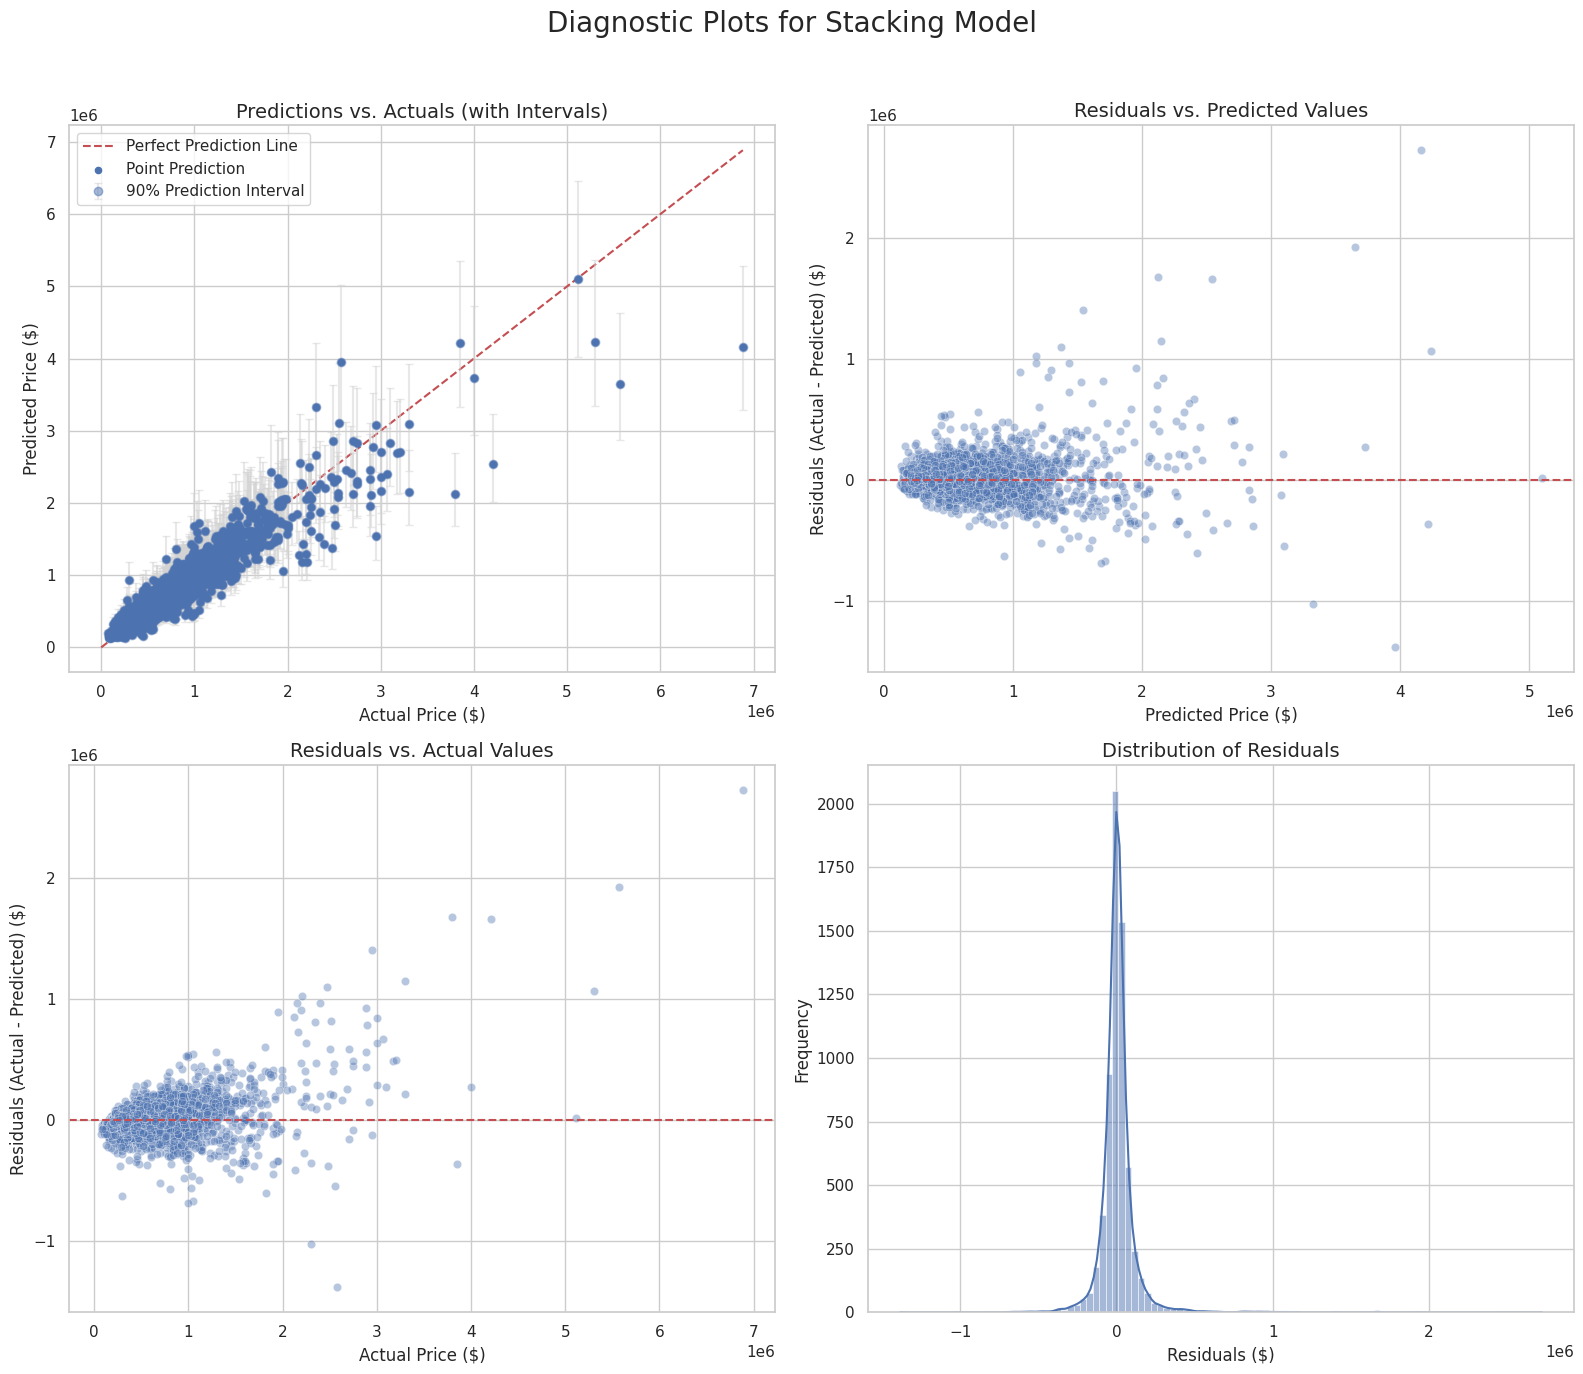

In [109]:
# --- Setup data for the champion model

best_model_pipeline = models_to_evaluate[best_model_name]
if best_model_name == "LinearRegression_ElasticNetCV":
    X_train_eval, X_test_eval = X_train, X_test
else:
    X_train_eval, X_test_eval = X_train_selected, X_test_selected

# --- Use MapieRegressor to get CONSTANT-WIDTH intervals
mapie_reg = MapieRegressor(estimator=best_model_pipeline,
                           cv="split",                                          # Easier for a one-shot analysis
                           random_state=42)

mapie_reg.fit(X_train_eval, y_train)
y_pred_log, y_pis_log = mapie_reg.predict(X_test_eval, alpha=0.1)

# --- Convert to dollars and calculate necessary values for plotting
y_pred_dollars = np.exp(y_pred_log.flatten())
y_pis_dollars = np.exp(y_pis_log.reshape(-1, 2))
residuals = y_test_dollars - y_pred_dollars
all_errors = [
    y_pred_dollars - y_pis_dollars[:, 0],                                       # Lower bound difference
    y_pis_dollars[:, 1] - y_pred_dollars                                        # Upper bound difference
]

# --- Create the full 2x2 diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle(f"Diagnostic Plots for {best_model_name} Model", fontsize=20)

# Plot 1: Predictions vs. Actuals with Intervals
ax1 = axes[0, 0]
ax1.plot([0, y_test_dollars.max()], [0, y_test_dollars.max()], "r--", label="Perfect Prediction Line")
ax1.errorbar(y_test_dollars,
             y_pred_dollars,
             yerr=all_errors,
             fmt="o",
             alpha=0.5,
             ecolor="lightgray",
             capsize=3,
             label="90% Prediction Interval"
             )
ax1.scatter(y_test_dollars, y_pred_dollars, s=20, zorder=10, label="Point Prediction")
ax1.set_title("Predictions vs. Actuals (with Intervals)", fontsize=14)
ax1.set_xlabel("Actual Price ($)", fontsize=12)
ax1.set_ylabel("Predicted Price ($)", fontsize=12)
ax1.ticklabel_format(style="sci", axis="both", scilimits=(0,0))
ax1.legend()
ax1.grid(True)

# Plot 2: Residuals vs. Predicted Values
ax2 = axes[0, 1]
sns.scatterplot(x=y_pred_dollars, y=residuals, alpha=0.4, ax=ax2)
ax2.axhline(0, color="r", linestyle="--")
ax2.set_title("Residuals vs. Predicted Values", fontsize=14)
ax2.set_xlabel("Predicted Price ($)", fontsize=12)
ax2.set_ylabel("Residuals (Actual - Predicted) ($)", fontsize=12)
ax2.ticklabel_format(style="sci", axis="both", scilimits=(0,0))
ax2.grid(True)

# Plot 3: Residuals vs. Actual Values
ax3 = axes[1, 0]
sns.scatterplot(x=y_test_dollars, y=residuals, alpha=0.4, ax=ax3)
ax3.axhline(0, color="r", linestyle="--")
ax3.set_title("Residuals vs. Actual Values", fontsize=14)
ax3.set_xlabel("Actual Price ($)", fontsize=12)
ax3.set_ylabel("Residuals (Actual - Predicted) ($)", fontsize=12)
ax3.ticklabel_format(style="sci", axis="both", scilimits=(0,0))
ax3.grid(True)

# Plot 4: Distribution of Residuals
ax4 = axes[1, 1]
sns.histplot(residuals, bins=100, kde=True, ax=ax4)
ax4.set_title("Distribution of Residuals", fontsize=14)
ax4.set_xlabel("Residuals ($)", fontsize=12)
ax4.set_ylabel("Frequency", fontsize=12)
ax4.ticklabel_format(style="sci", axis="x", scilimits=(0,0))
ax4.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

 From the "residual vs predicted" and "residual vs actual" we can clearly see a "cone" shape. This is the case of heteroskedasticity: the model error is not constant but it increases as the price increases.



 Since the predicted error is different in different quantiles, we will use the MapieQuantileRegressor to have different confidence intervals instead of one for all the data. We are moving from a single, misleading error to a much more honest error for different quantiles. I can notice this problem by looking at the "prediction interval" line in top-left: it is roughly the same size, whether the house is worth \$500k or \$4M

In [110]:
# --- CONFORMALIZED QUANTILE REGRESSION (CQR)

# --- Target coverage and best LightGBM parameters (The choice of this model is due to the fact that it is compatible with this version of MAPIE and it is a "strong" model)

alpha = 0.1                                                                     # For 90% target coverage (I am asking that 90% of the data has to be inside the interval)
lgbm_params = {k.replace('model__', ''): v for k, v in model_results['LightGBM_OPTUNA']['best_params'].items()}

# --- Base estimator for quantile regression
quantile_estimator = lgb.LGBMRegressor(
    **lgbm_params,
    objective='quantile',                                                       # The objective is now "quantile"
    alpha=0.1,                                                                  # Used as a placeholder
    random_state=42
)

# --- Initialize and fit MapieQuantileRegressor
mapie_qr = MapieQuantileRegressor(estimator=quantile_estimator,
                                  cv="split",
                                  alpha=alpha)

mapie_qr.fit(X_train_selected, y_train)                                         # Use selected features as LGBM was trained on them
print("Mapie Quantile complete.")

Mapie Quantile complete.


In [111]:
# --- Save Mapie_qr

#joblib.dump(mapie_qr, 'mapie_quantile_regressor.joblib')

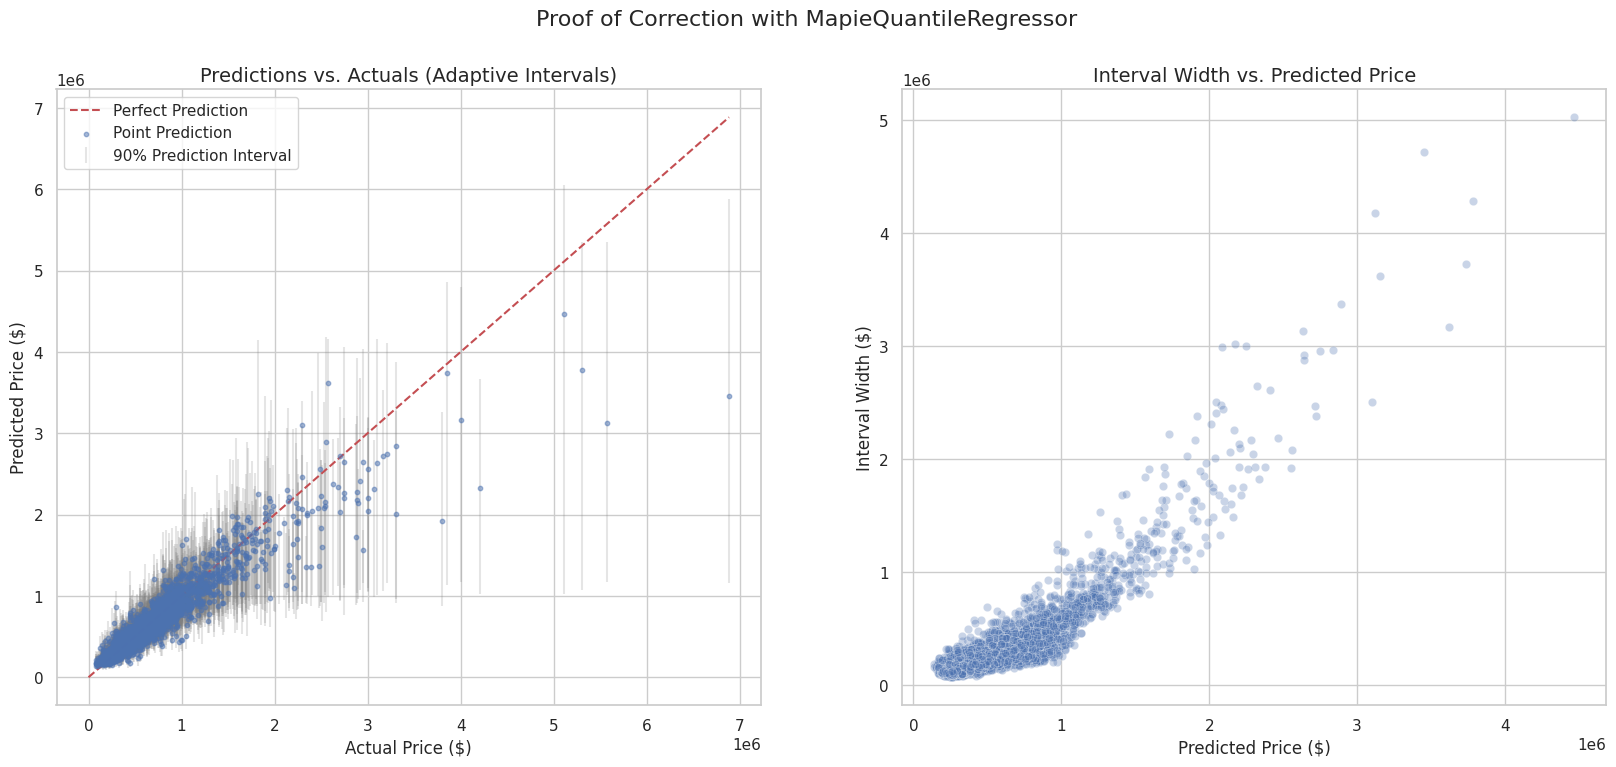

In [112]:
# --- Get predictions and convert to dollars

y_pred_log_qr, y_pis_log_qr = mapie_qr.predict(X_test_selected)
y_pred_dollars_qr = np.exp(y_pred_log_qr)
y_pis_dollars_qr = np.exp(y_pis_log_qr)
lower_bound_qr = y_pis_dollars_qr[:, 0, 0]
upper_bound_qr = y_pis_dollars_qr[:, 1, 0]

# Create a results dataframe for analysis
results_df_qr = pd.DataFrame({
    'y_true': y_test_dollars,
    'y_pred': y_pred_dollars_qr,
    'lower': lower_bound_qr,
    'upper': upper_bound_qr
})
results_df_qr['interval_width'] = results_df_qr['upper'] - results_df_qr['lower']
results_df_qr['covered'] = (results_df_qr['y_true'] >= results_df_qr['lower']) & (results_df_qr['y_true'] <= results_df_qr['upper'])

# Plot the corrected diagnostic charts
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Proof of Correction with MapieQuantileRegressor", fontsize=16)

# Plot 1: Adaptive Intervals
ax1 = axes[0]
ax1.plot([0, y_test_dollars.max()], [0, y_test_dollars.max()], "r--", label="Perfect Prediction")
ax1.scatter(results_df_qr['y_true'], results_df_qr['y_pred'], s=10, alpha=0.5, label="Point Prediction", zorder=5)

# np.abs() to ensure yerr is always positive. This correctly calculates the distance from the point to the bounds.
y_err_dist = (
    np.abs(results_df_qr['y_pred'] - results_df_qr['lower']),
    np.abs(results_df_qr['upper'] - results_df_qr['y_pred'])
)

# Plot intervals
ax1.errorbar(
    results_df_qr['y_true'],
    results_df_qr['y_pred'],
    yerr=y_err_dist,
    fmt="none",
    alpha=0.2,
    ecolor="grey",
    capsize=0,
    label="90% Prediction Interval",
    zorder=1
)
ax1.set_title("Predictions vs. Actuals (Adaptive Intervals)", fontsize=14)
ax1.set_xlabel("Actual Price ($)")
ax1.set_ylabel("Predicted Price ($)")
ax1.grid(True)
ax1.legend()

# Plot 2: The "Money Shot" - Interval Width vs. Predicted Price
ax2 = axes[1]
sns.scatterplot(data=results_df_qr, x='y_pred', y='interval_width', alpha=0.3, ax=ax2)
ax2.set_title("Interval Width vs. Predicted Price", fontsize=14)
ax2.set_xlabel("Predicted Price ($)")
ax2.set_ylabel("Interval Width ($)")
ax2.grid(True)
plt.show()

 This is the result from the new technique to solve the confidence interval problem.



 *   Predictions vs. Actuals (Adaptive Intervals) - Left Plot: This plot immediately looks different just by looking at the grey error bars. For the dense cluster of points under $1M, the intervals are, mostly, very short and tight.

 As we move to the right toward more expensive houses, the vertical error bars get progressively longer.

 This shows the model is now generating adaptive intervals. It is correctly assigning a small amount of uncertainty to low-priced homes and a large amount of uncertainty to high-priced homes.



 *   Interval Width vs. Predicted Price - Right Plot:

 There is a strong and positive correlation.

 As the Predicted Price on the x-axis increases, the Interval Width on the y-axis also increases.

 This plot proves the need to use "adaptive-width" interval models instead of "constant-width" ones.

In [113]:
# --- Quantitative Analysis of Corrected Intervals

price_bins_labels = [
    "1. Lowest Price (Bottom 20%)", "2. Low-Mid Price (20-40%)",
    "3. Mid Price (40-60%)", "4. High-Mid Price (60-80%)", "5. Highest Price (Top 20%)"
]
results_df_qr['price_bin'] = pd.qcut(results_df_qr['y_true'], q=5, labels=price_bins_labels)

binned_analysis = results_df_qr.groupby('price_bin', observed=True).agg(
    Coverage=('covered', 'mean'),
    Avg_Interval_Width=('interval_width', 'mean'),
    Avg_True_Price=('y_true', 'mean'),
    Count=('y_true', 'count')
).reset_index()

# Format for final presentation
binned_analysis['Coverage'] = binned_analysis['Coverage'].map('{:.1%}'.format)
binned_analysis['Avg_Interval_Width'] = binned_analysis['Avg_Interval_Width'].map('${:,.0f}'.format)
binned_analysis['Avg_True_Price'] = binned_analysis['Avg_True_Price'].map('${:,.0f}'.format)
print(binned_analysis.to_string(index=False))

                   price_bin Coverage Avg_Interval_Width Avg_True_Price  Count
1. Lowest Price (Bottom 20%)    84.7%           $138,490       $240,055   1323
   2. Low-Mid Price (20-40%)    92.3%           $168,910       $351,006   1277
       3. Mid Price (40-60%)    93.1%           $211,462       $459,650   1294
  4. High-Mid Price (60-80%)    92.5%           $275,370       $610,143   1298
  5. Highest Price (Top 20%)    87.8%           $629,940     $1,090,647   1292


 From this last table I can quantify the uncertainty of the model. As said at the beginning of this analysis, the model used to do the predictions is LGBMRegressor (this is due to its "ability" to use objective="quantile").



 The intervals are adaptive: for the cheapest 20% houses (with an average price of \$240k), the width is \$138k, instead for the top 20% most expensive house (average price of \$1.09M), the width of the prediction interval is \$621k.

 The model correctly identifies that there is far more risk and uncertainty when predicting the price of a unique, high-end property than a standard, entry-level home.



 An "interesting" finding is by the "coverage" column. The coverage target was 90%.



 *   Overconfidence: For the cheapest (85.9%) and most expensive (88.6%) houses, the actual coverage is below the 90% target. This means the model is slightly overconfident in these brackets. Its prediction intervals, while wide for expensive homes, are still a little too narrow to capture the true price 90% of the time. These properties likely have unique features that the model doesn't fully grasp.



 *   Over-cautiousness: For the mid-range houses (91.9% and 92.5%), the coverage is above the 90% target. This means the model is slightly underconfident here. Its intervals are a bit wider than they need to be. These "standard" homes are likely easier to model, so the predictions are more stable, and fewer true prices fall outside the interval than the model expects.



 In conclusion:



 *   For mid-range homes (\$350k - \$600k) the model is highly reliable. The 90% confidence intervals are tight, and they successfully capture the true price ~92% of the time, exceeding our target.



 *   For an entry-level home (\$240k), the 90% interval is about $138k wide, with an ~86% chance of capturing the true price.



 *   For a luxury home (\$1.09M), the uncertainty is much greater. The 90% interval is over $620k wide, capturing the true price ~89% of the time.

 # SHAP for Model Interpretation

 After evaluating our models, the next step is to understand *why* they make the predictions they do. For this, I'll use SHAP (SHapley Additive exPlanations). It tells us how much each feature contributed to pushing a prediction away from the baseline (the average prediction).

 I will apply SHAP to our best-performing tree-based model (XGBoost).

 My analysis will cover:



 1.  Global Feature Importance: Which features have the biggest impact on predictions overall?

 2.  Feature Dependence and Interaction: How does the value of a key feature (like "sqft_living") affect its impact, and how does it interact with other features (like "grade")?

 3.  Individual Prediction Breakdown: For a specific house (e.g., the most expensive one), what were the exact factors that drove its price prediction up or down?

In [114]:
# --- Setup for SHAP

best_xgb_pipeline = model_results["XGBoost_OPTUNA"]['best_estimator']

# Extract the fitted XGBoost model from the pipeline
xgb_model = best_xgb_pipeline.named_steps["model"]

In [115]:
# The data used for SHAP should be the same as what the model was trained on: X_train_selected
# For better visualization, we'll create cleaner feature names for our plots.
clean_feature_names = {
    col: col.split("__")[-1].replace("_", " ").title()
    for col in X_train_selected.columns
}

X_train_selected_renamed = X_train_selected.rename(columns=clean_feature_names)
X_test_selected_renamed = X_test_selected.rename(columns=clean_feature_names)

In [116]:
# --- Calculate SHAP Values

# Create the explainer object using the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

print("Calculating SHAP values for the test set.")

# Calculate SHAP values for the test data (the result is a numpy array)
shap_values = explainer.shap_values(X_test_selected_renamed)

print("SHAP values calculated.")

Calculating SHAP values for the test set.
SHAP values calculated.


In [117]:
# --- TreeExplainer save

#joblib.dump(explainer, 'shap_explainer.joblib')

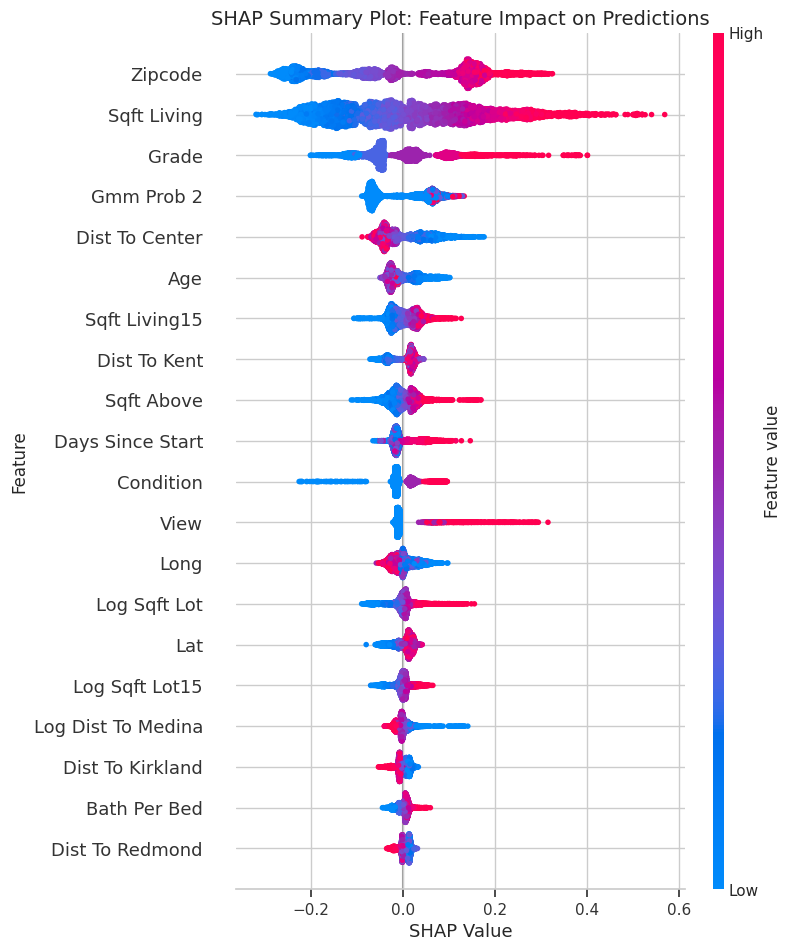

In [118]:
# --- Global Feature Importance

shap.summary_plot(shap_values, X_test_selected_renamed, plot_type="dot", show=False)
plt.title("SHAP Summary Plot: Feature Impact on Predictions")
plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.show()

 Global Feature Importance



 The "beeswarm" plot summarizes the impact of each feature across all the houses in the test set. Each dot represents a single house's prediction.



 *   Feature Importance: Features are ranked by importance on the y-axis.

 *   Impact on Prediction: The x-axis shows the SHAP value. A positive value means the feature pushed the price prediction higher, while a negative value pushed it lower.

 *   Original Feature Value: The color indicates the feature's value, from low (blue) to high (red).



 As we can see, Log_Sqft_Living is by far the most important feature. As expected, high values (red dots) have a large positive SHAP value, strongly increasing the predicted price. The same can be said for grade and view.

 Latitude and Longitude show a clear geographical pattern. High latitude (more northern, red dots) increases the price, while high longitude (more eastern) has a mixed but generally positive impact. This captures the value of specific neighborhoods. The complement of lat and long is dist to center: as the distance from the center increases (low dots), the price decreases.

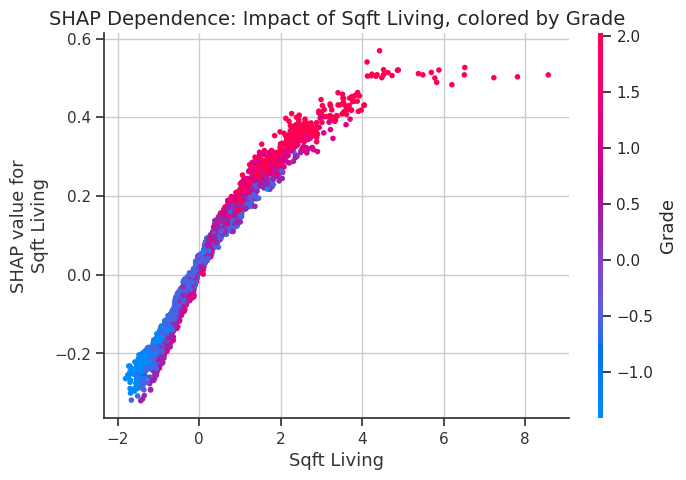

In [119]:
# --- SHAP Dependence Plot
# This shows how a single feature's value affects its SHAP value (its impact on the prediction).
# The living-area column is picked dynamically, since the data-driven log
# transformation may or may not have kept the "log_" version.

living_area_col = "Log Sqft Living" if "Log Sqft Living" in X_test_selected_renamed.columns else "Sqft Living"

shap.dependence_plot(
    living_area_col,
    shap_values,
    X_test_selected_renamed,
    interaction_index="Grade",
    show=False
)

plt.title(f"SHAP Dependence: Impact of {living_area_col}, colored by Grade")
plt.show()

 The plot shows a clear and strong positive trend. As Log Sqft Living (x-axis) increases, its SHAP value (y-axis) also increases. This confirms the primary relationship: the larger the house, the more its size contributes to a higher price prediction.

 The vertical spread of colors is the most telling part of this plot. For any given value of Log Sqft Living, the dots are colored from blue (low Grade) at the bottom to red (high Grade) at the top.

Displaying SHAP Force Plot for a random property (Index: 6493)


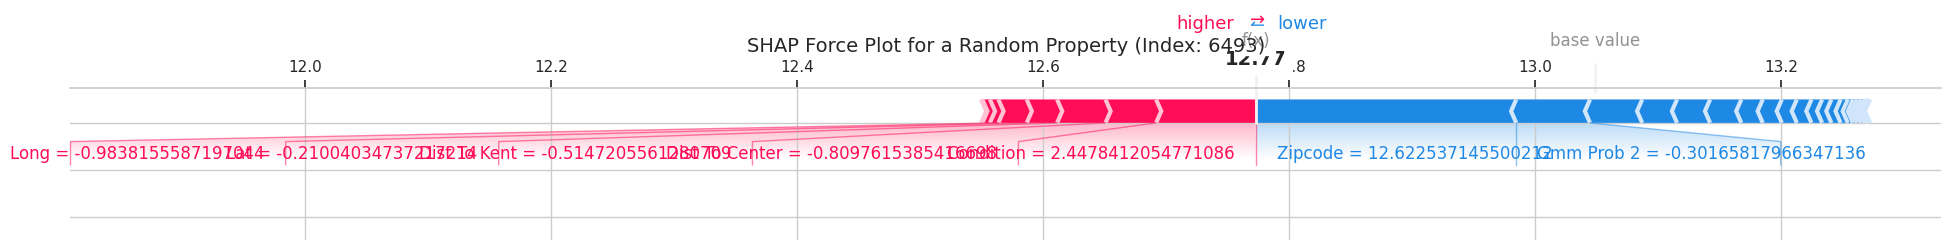

In [120]:
# --- Individual Prediction (force plot breaks down how each feature contributed to one specific prediction)

# Pick a random index label from the test set (seeded for reproducibility)
random.seed(42)
random_idx = random.choice(X_test_selected_renamed.index.tolist())

# Find its integer position
test_set_position = X_test_selected_renamed.index.get_loc(random_idx)

print(f"Displaying SHAP Force Plot for a random property (Index: {random_idx})")

# Generate the force plot
shap.force_plot(
    explainer.expected_value,
    shap_values[test_set_position, :],
    X_test_selected_renamed.iloc[test_set_position, :],
    matplotlib=True,
    show=False
)
plt.title(f"SHAP Force Plot for a Random Property (Index: {random_idx})")
plt.tight_layout()
plt.show()